<a href="https://colab.research.google.com/github/WooSeungJi/WM811K-Project/blob/main/Ram_%EC%A0%88%EC%95%BD_WM_811K_Wafer_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# WM-811K Wafer Map Defect Classification
# RAM 부족 해결 버전 전체 코드
# ============================================================
#
# 핵심 변경점
# 1. 전체 waferMap 이미지를 한 번에 X 배열로 만들지 않음
# 2. none 클래스는 너무 많기 때문에 다운샘플링
# 3. tf.data.Dataset.from_generator()를 사용해서 배치 단위로 처리
# 4. float32 사용
# 5. 불필요한 DataFrame은 중간중간 삭제해서 RAM 확보
#
# ============================================================


# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import os
import gc
import sys
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# ============================================================
# 1. 기본 설정
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

IMG_SIZE = 64
BATCH_SIZE = 64

# none 클래스가 너무 많기 때문에 처음에는 15000개만 사용
# RAM이 부족하면 8000 또는 10000으로 줄이면 됨
NONE_LIMIT = 15000

# 학습 epoch
EPOCHS = 30


# ============================================================
# 2. Google Drive 연결
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 3. 데이터 경로 설정
# ============================================================

DATA_PATH = "/content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl"
OUTPUT_DIR = "/content/drive/MyDrive/ML Project/WM811K/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("파일 존재 여부:", os.path.exists(DATA_PATH))
print("데이터 경로:", DATA_PATH)
print("결과 저장 폴더:", OUTPUT_DIR)

Mounted at /content/drive
파일 존재 여부: True
데이터 경로: /content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl
결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs


In [4]:
# ============================================================
# 4. WM-811K pickle 파일 안전 로드 함수
# ============================================================

def load_wm811k_pickle(path):
    """
    WM-811K의 LSWMD.pkl 파일은 예전 pandas 버전에서 저장된 pickle인 경우가 많다.

    그래서 최신 pandas에서 바로 pd.read_pickle(path)를 하면
    ModuleNotFoundError: No module named 'pandas.indexes'
    같은 오류가 발생할 수 있다.

    이 함수는 pandas.indexes 관련 모듈 이름을 최신 pandas 구조에 맞게 임시 연결한 뒤,
    pickle 파일을 최대한 안전하게 불러온다.
    """

    try:
        import pandas.core.indexes.base
        import pandas.core.indexes.numeric
        import pandas.core.indexes.datetimes
        import pandas.core.indexes.timedeltas
        import pandas.core.indexes.period
        import pandas.core.indexes.multi

        sys.modules["pandas.indexes"] = pd.core.indexes
        sys.modules["pandas.indexes.base"] = pandas.core.indexes.base
        sys.modules["pandas.indexes.numeric"] = pandas.core.indexes.numeric
        sys.modules["pandas.indexes.datetimes"] = pandas.core.indexes.datetimes
        sys.modules["pandas.indexes.timedeltas"] = pandas.core.indexes.timedeltas
        sys.modules["pandas.indexes.period"] = pandas.core.indexes.period
        sys.modules["pandas.indexes.multi"] = pandas.core.indexes.multi

    except Exception as e:
        print("pandas 호환 alias 설정 중 경고:", e)

    try:
        df = pd.read_pickle(path)
        print("pd.read_pickle로 로드 성공")
        return df

    except Exception as e1:
        print("pd.read_pickle 실패:", e1)
        print("pickle.load encoding='latin1' 방식으로 재시도")

    with open(path, "rb") as f:
        df = pickle.load(f, encoding="latin1")

    print("pickle.load로 로드 성공")
    return df


In [5]:
# ============================================================
# 5. 데이터 로드
# ============================================================

df = load_wm811k_pickle(DATA_PATH)

print()
print("전체 데이터 shape:", df.shape)
print()
print("컬럼 목록:")
print(df.columns)

pandas 호환 alias 설정 중 경고: No module named 'pandas.core.indexes.numeric'
pd.read_pickle로 로드 성공

전체 데이터 shape: (811457, 6)

컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [6]:
# ============================================================
# 6. failureType에서 실제 label 추출
# ============================================================

def extract_label(x):
    """
    WM-811K의 failureType은 보통 [[none]], [[Center]] 같은 구조로 들어 있다.
    따라서 x[0][0]을 꺼내면 실제 라벨명이 나온다.
    """

    try:
        label = x[0][0]

        if label == "":
            return "unknown"

        return label

    except:
        return "unknown"


df["label"] = df["failureType"].apply(extract_label)

print()
print("전체 label 분포:")
print(df["label"].value_counts(dropna=False))


전체 label 분포:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. unknown 제거
# ============================================================

df_labeled = df[df["label"] != "unknown"].copy()

print()
print("라벨링된 데이터 개수:", len(df_labeled))
print()
print("라벨링된 데이터 클래스 분포:")
print(df_labeled["label"].value_counts())


라벨링된 데이터 개수: 172950

라벨링된 데이터 클래스 분포:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. 원본 df 삭제해서 RAM 확보
# ============================================================

del df
gc.collect()

print()
print("불필요한 원본 df 삭제 완료")



불필요한 원본 df 삭제 완료


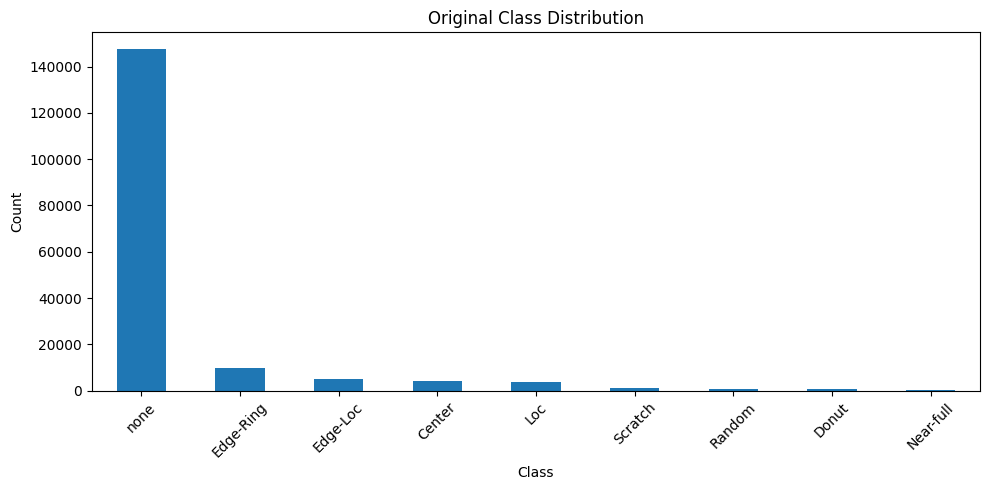

In [9]:
# ============================================================
# 9. 클래스 분포 시각화
# ============================================================

label_counts = df_labeled["label"].value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


샘플링 후 데이터 개수: 40519

샘플링 후 클래스 분포:
label
none         15000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64

샘플링 이후 불필요한 데이터 삭제 완료


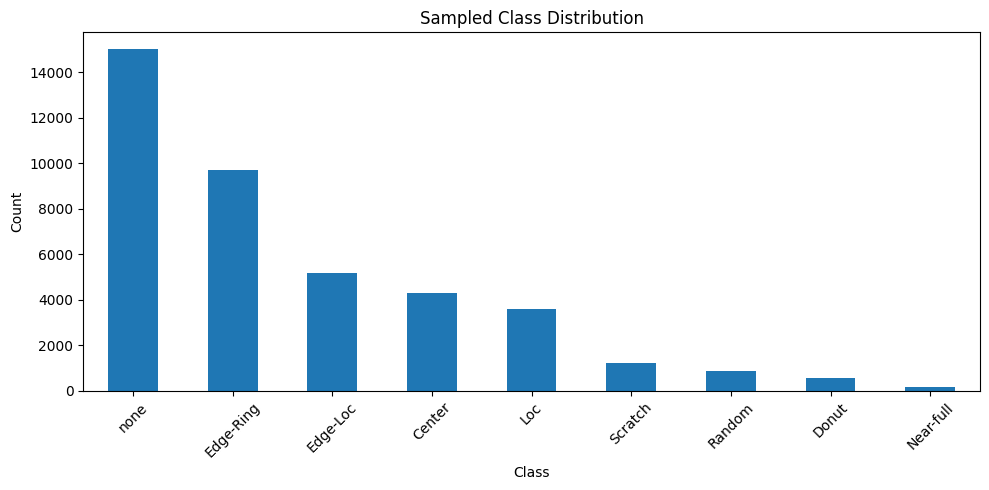


클래스 이름:
[np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]

클래스 개수: 9

라벨 인코딩 매핑:
0 -> Center
1 -> Donut
2 -> Edge-Loc
3 -> Edge-Ring
4 -> Loc
5 -> Near-full
6 -> Random
7 -> Scratch
8 -> none

train 개수: 32415
validation 개수: 4052
test 개수: 4052


In [10]:
# ============================================================
# 10. none 클래스 다운샘플링 + defect 클래스 전체 사용
# ============================================================

df_none = df_labeled[df_labeled["label"] == "none"]
df_defect = df_labeled[df_labeled["label"] != "none"]

df_none_sampled = df_none.sample(
    n=min(NONE_LIMIT, len(df_none)),
    random_state=RANDOM_STATE
)

df_sampled = pd.concat([df_none_sampled, df_defect], axis=0)
df_sampled = df_sampled.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print()
print("샘플링 후 데이터 개수:", len(df_sampled))
print()
print("샘플링 후 클래스 분포:")
print(df_sampled["label"].value_counts())


# ============================================================
# 11. 불필요한 DataFrame 삭제해서 RAM 확보
# ============================================================

del df_labeled
del df_none
del df_defect
del df_none_sampled

gc.collect()

print()
print("샘플링 이후 불필요한 데이터 삭제 완료")


# ============================================================
# 12. 샘플링 후 클래스 분포 시각화
# ============================================================

sampled_label_counts = df_sampled["label"].value_counts()

plt.figure(figsize=(10, 5))
sampled_label_counts.plot(kind="bar")
plt.title("Sampled Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 13. 라벨 인코딩
# ============================================================

label_encoder = LabelEncoder()

df_sampled["label_encoded"] = label_encoder.fit_transform(df_sampled["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print()
print("클래스 이름:")
print(class_names)

print()
print("클래스 개수:", num_classes)

print()
print("라벨 인코딩 매핑:")
for i, name in enumerate(class_names):
    print(i, "->", name)


# ============================================================
# 14. train / validation / test 분리
# ============================================================

indices = np.arange(len(df_sampled))
labels_encoded = df_sampled["label_encoded"].values

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    labels_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels_encoded
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print()
print("train 개수:", len(train_idx))
print("validation 개수:", len(val_idx))
print("test 개수:", len(test_idx))



#**여기서 부터 CNN 학습용 코드임**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
파일 존재 여부: True
데이터 경로: /content/drive/MyDrive/ML Project/WM811K/LSWMD.pkl
결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs
pandas 호환 alias 설정 중 경고: No module named 'pandas.core.indexes.numeric'
pd.read_pickle로 로드 성공

전체 데이터 shape: (811457, 6)

컬럼 목록:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

전체 label 분포:
label
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

라벨링된 데이터 개수: 172950

라벨링된 데이터 클래스 분포:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: i

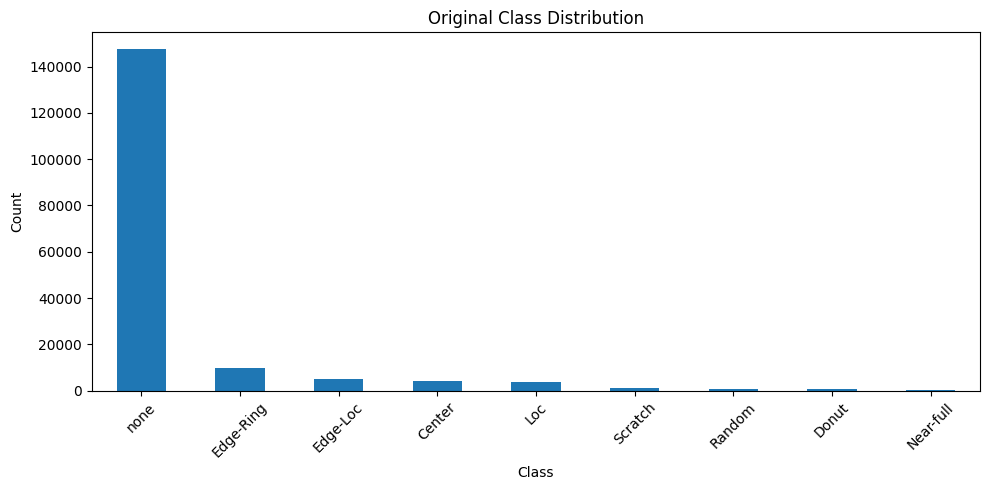


샘플링 후 데이터 개수: 40519

샘플링 후 클래스 분포:
label
none         15000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64

샘플링 이후 불필요한 데이터 삭제 완료


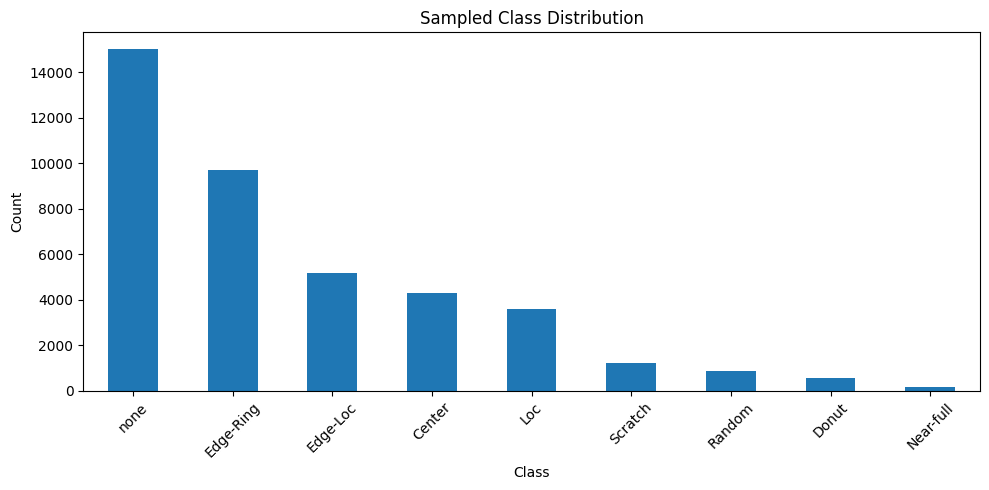


클래스 이름:
[np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]

클래스 개수: 9

라벨 인코딩 매핑:
0 -> Center
1 -> Donut
2 -> Edge-Loc
3 -> Edge-Ring
4 -> Loc
5 -> Near-full
6 -> Random
7 -> Scratch
8 -> none

train 개수: 32415
validation 개수: 4052
test 개수: 4052

tf.data Dataset 생성 완료


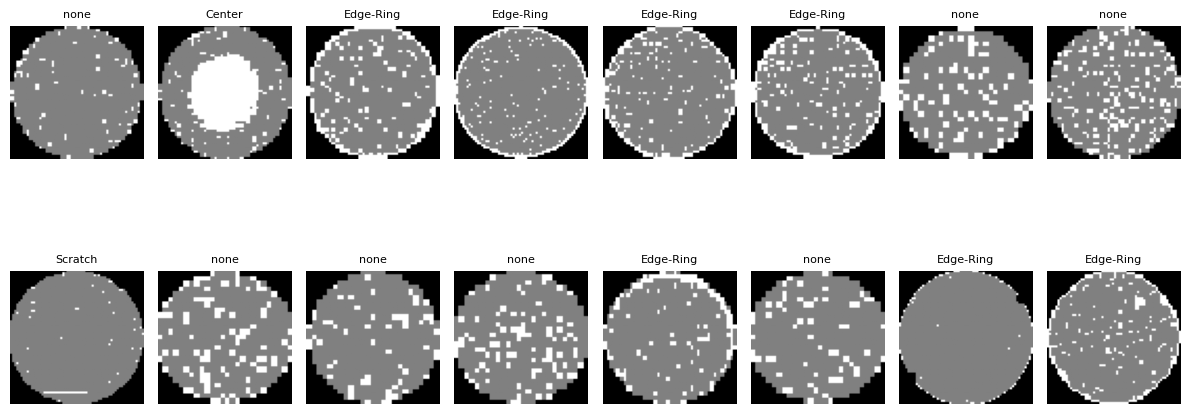


class_weight:
{0: 1.0485201358563805, 1: 8.111861861861861, 2: 0.867662410664097, 3: 0.4650912534435262, 4: 1.2531895151936905, 5: 30.26610644257703, 6: 5.197210197210198, 7: 3.7713787085514836, 8: 0.3001388888888889}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,241 (434.54 KB)

 Trainable params: 110,793 (432.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 84s 136ms/step - accuracy: 0.5804 - loss: 1.1297 - val_accuracy: 0.1431 - val_loss: 3.8546 - learning_rate: 0.0010
Epoch 2/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 67s 127ms/step - accuracy: 0.7160 - loss: 0.7853 - val_accuracy: 0.6730 - val_loss: 0.8236 - learning_rate: 0.0010
Epoch 3/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.7688 - loss: 0.6579 - val_accuracy: 0.8055 - val_loss: 0.5616 - learning_rate: 0.0010
Epoch 4/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 68s 126ms/step - accuracy: 0.8128 - loss: 0.5401 - val_accuracy: 0.7957 - val_loss: 0.6449 - learning_rate: 0.0010
Epoch 5/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 68s 128ms/step - accuracy: 0.8299 - loss: 0.4813 - val_accuracy: 0.8122 - val_loss: 0.6341 - learning_rate: 0.0010
Epoch 6/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.8662 - loss: 0.3814 - val_accuracy: 0.8685 - val_loss: 0.3812 - learning_rate: 5.0000e-04
Epoch 7/30
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - accuracy:

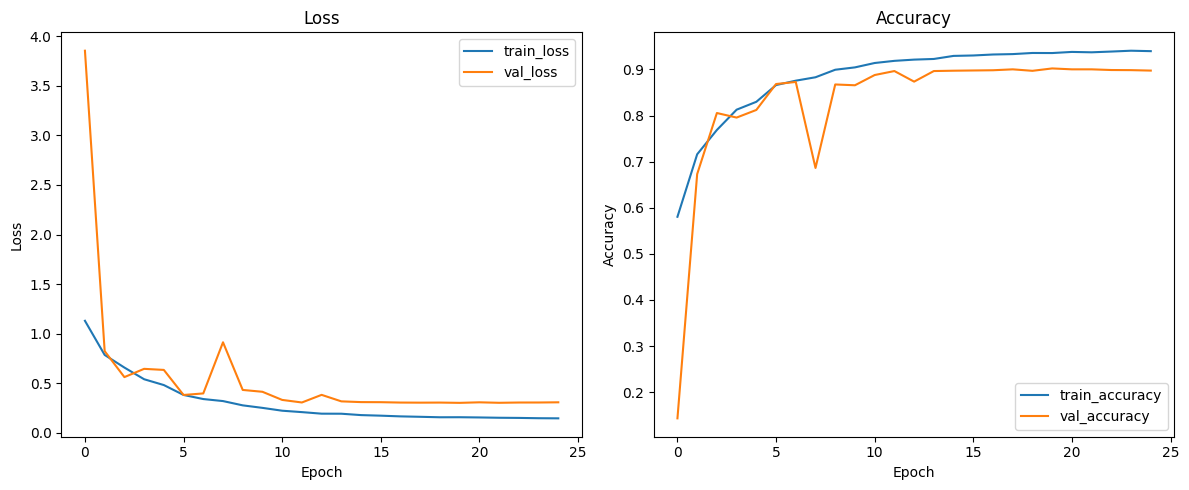

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9099 - loss: 0.2753

Test Loss: 0.27532196044921875
Test Accuracy: 0.9099210500717163


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# ============================================================
# 15. waferMap 전처리 함수
# ============================================================

def resize_wafer_map(wafer_map, img_size=IMG_SIZE):
    """
    wafer_map 하나를 CNN 입력 형태로 바꾼다.

    원본 wafer map 값:
    0: wafer 바깥 또는 빈 영역
    1: 정상 die
    2: 불량 die

    처리 과정:
    1. numpy array로 변환
    2. channel 차원 추가
    3. TensorFlow resize 사용
    4. 0~2 값을 0~1 범위로 정규화
    """

    wafer_map = np.array(wafer_map, dtype=np.float32)

    wafer_map = np.expand_dims(wafer_map, axis=-1)

    wafer_map = tf.image.resize(
        wafer_map,
        size=(img_size, img_size),
        method="nearest"
    )

    wafer_map = wafer_map / 2.0

    return wafer_map


# ============================================================
# 16. generator 함수
# ============================================================

def wafer_generator(index_array):
    """
    index_array에 들어 있는 index를 하나씩 읽으면서
    waferMap과 label을 생성한다.

    중요한 점:
    X 전체 배열을 미리 만들지 않는다.
    필요할 때마다 하나씩 꺼내서 처리한다.
    """

    for idx in index_array:
        wafer_map = df_sampled.loc[idx, "waferMap"]
        label = df_sampled.loc[idx, "label_encoded"]

        image = resize_wafer_map(wafer_map)

        yield image, np.int32(label)


# ============================================================
# 17. tf.data Dataset 생성 함수
# ============================================================

def make_dataset(index_array, shuffle=False):
    """
    TensorFlow Dataset을 만든다.

    shuffle=True이면 학습 데이터처럼 섞어서 사용한다.
    validation/test는 shuffle=False로 둔다.
    """

    dataset = tf.data.Dataset.from_generator(
        lambda: wafer_generator(index_array),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=2048, seed=RANDOM_STATE)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(train_idx, shuffle=True)
val_ds = make_dataset(val_idx, shuffle=False)
test_ds = make_dataset(test_idx, shuffle=False)

print()
print("tf.data Dataset 생성 완료")


# ============================================================
# 18. 샘플 이미지 확인
# ============================================================

plt.figure(figsize=(12, 6))

sample_batch = next(iter(train_ds))
sample_images, sample_labels = sample_batch

for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[int(sample_labels[i])], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 19. class weight 계산
# ============================================================

train_labels = df_sampled.loc[train_idx, "label_encoded"].values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_labels), class_weights_array)
}

print()
print("class_weight:")
print(class_weight_dict)





In [ ]:

# ============================================================
# 20. CNN 모델 생성 함수
# ============================================================

def build_light_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=num_classes):
    """
    RAM과 GPU 메모리를 너무 많이 쓰지 않는 가벼운 CNN 모델이다.

    처음부터 큰 모델을 쓰면 Colab에서 또 터질 수 있으므로,
    Conv2D 필터 수를 32 -> 64 -> 128 정도로 제한한다.
    """

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


# ============================================================
# 21. 모델 생성 및 컴파일
# ============================================================

model = build_light_cnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 22. callback 설정
# ============================================================

best_model_path = os.path.join(OUTPUT_DIR, "best_light_cnn.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


# ============================================================
# 23. 모델 학습
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


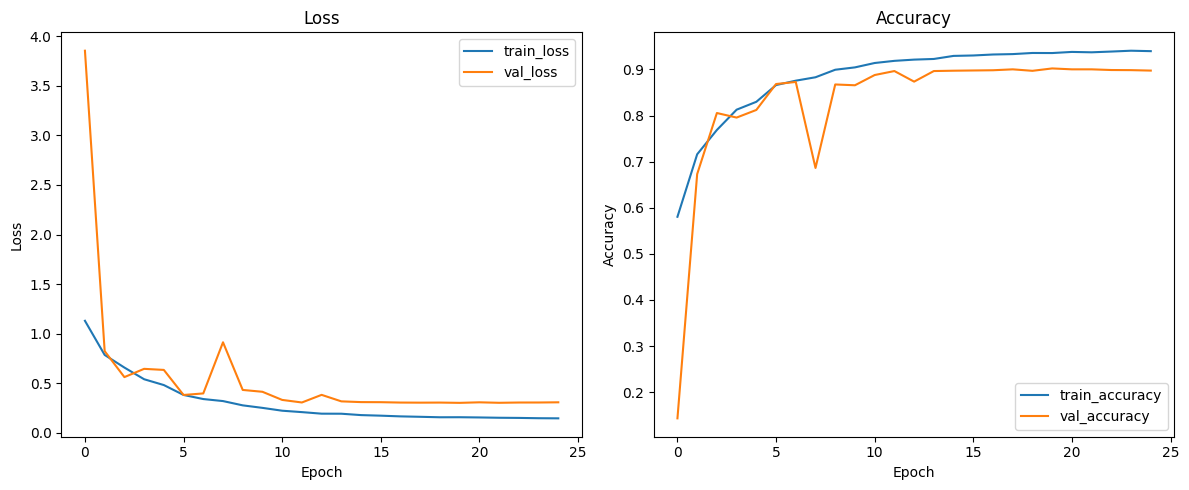

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9099 - loss: 0.2753

Test Loss: 0.27532196044921875
Test Accuracy: 0.9099210500717163
예측 완료
y_true shape: (4052,)
y_pred shape: (4052,)

Accuracy: 0.9099210266535045
Balanced Accuracy: 0.8844715634461152
Macro F1-score: 0.8663047054073619
Weighted F1-score: 0.910084973300348
Macro Recall: 0.8844715634461152

Classification Report:
              precision    recall  f1-score   support

      Center     0.9109    0.8558    0.8825       430
       Donut     0.7273    0.8727    0.7934        55
    Edge-Loc     0.8577    0.8709    0.8642       519
   Edge-Ring     0.9906    0.9752    0.9828       968
         Loc     0.7309    0.7167    0.7237       360
   Near-full     0.8824    1.0000    0.9375        15
      Random     0.8681    0.9186    0.8927        86
     Scratch     0.7480    0.7983    0.7724       119
        none     0.9432    0.9520    0.9476      1500

    accuracy                         0.9099      4052
   macro avg    

<Figure size 1000x1000 with 0 Axes>

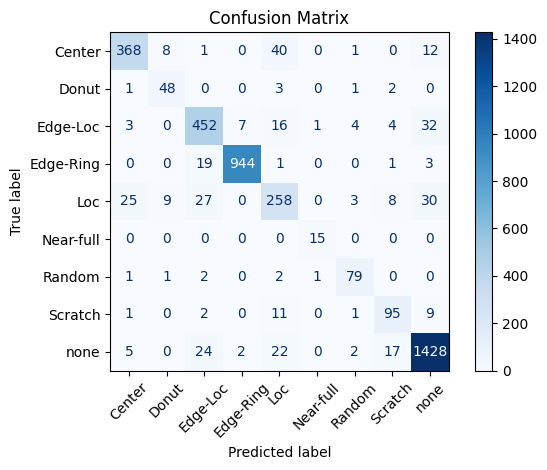


결과 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/light_cnn_result.csv

모델 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/final_light_cnn.keras

전체 코드 실행 완료


In [ ]:
# ============================================================
# 24. 학습 곡선 시각화
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 25. test 데이터 평가
# ============================================================

test_loss, test_acc = model.evaluate(test_ds)

print()
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


# ============================================================
# 26. y_true, y_pred 생성
# ============================================================

# y_true, y_pred 생성

# ============================================================
# y_true, y_pred 생성
# ============================================================

y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    pred_probs = model.predict(batch_images, verbose=0)

    pred_probs = np.array(pred_probs)

    pred_labels = np.argmax(pred_probs, axis=-1)

    y_true.extend(batch_labels.numpy().reshape(-1))

    if np.ndim(pred_labels) == 0:
        y_pred.append(pred_labels.item())
    else:
        y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("예측 완료")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


# ============================================================
# 27. 성능 지표 출력
# ============================================================

acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
macro_recall = recall_score(y_true, y_pred, average="macro")

print()
print("Accuracy:", acc)
print("Balanced Accuracy:", balanced_acc)
print("Macro F1-score:", macro_f1)
print("Weighted F1-score:", weighted_f1)
print("Macro Recall:", macro_recall)

print()
print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


# ============================================================
# 28. Confusion Matrix 출력
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 29. 결과 저장
# ============================================================

result_dict = {
    "model": "Light CNN with tf.data generator",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "none_limit": NONE_LIMIT,
    "num_classes": num_classes,
    "class_names": class_names,
    "test_accuracy": acc,
    "balanced_accuracy": balanced_acc,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "macro_recall": macro_recall
}

result_df = pd.DataFrame([result_dict])

result_csv_path = os.path.join(OUTPUT_DIR, "light_cnn_result.csv")
result_df.to_csv(result_csv_path, index=False, encoding="utf-8-sig")

print()
print("결과 저장 완료:")
print(result_csv_path)


# ============================================================
# 30. 모델 저장
# ============================================================

final_model_path = os.path.join(OUTPUT_DIR, "final_light_cnn.keras")
model.save(final_model_path)

print()
print("모델 저장 완료:")
print(final_model_path)


# ============================================================
# 31. 마무리 RAM 정리
# ============================================================

gc.collect()

print()
print("전체 코드 실행 완료")

현재 코드가 하는 일 (요약)
1. 데이터 불러오기
WM-811K 데이터셋(LSWMD.pkl) 로드
failureType에서 실제 결함 라벨 추출
2. 클래스 불균형 완화

현재는 데이터 증강을 하지 않음

대신 두 가지 방법 사용

(1) Down Sampling

none 클래스가 너무 많아서 최대 15,000개만 사용

(2) Class Weight

샘플 수가 적은 클래스에 더 큰 가중치 부여
Scratch, Donut 같은 희소 클래스 학습 강화
3. 메모리 최적화

Google Colab RAM 부족 문제 해결을 위해

전체 이미지를 한 번에 메모리에 올리지 않음
tf.data.Dataset.from_generator() 사용
불필요한 데이터 삭제
float32 사용
4. CNN 입력 생성

웨이퍼 맵을

원본 크기
↓
64×64 이미지
↓
0~1 정규화

로 변환

5. CNN 모델 학습

간단한 CNN 사용

Conv(32)
↓
Conv(64)
↓
Conv(128)
↓
Dense
↓
Softmax
6. 성능 평가

다음 지표 계산

Accuracy
Balanced Accuracy
Macro F1
Recall
Confusion Matrix

# **이제 Feature Engineering 실험**

In [11]:
# ============================================================
# 20. Feature Engineering용 라이브러리 추가
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from scipy.ndimage import label as connected_component_label
import joblib

In [12]:
# ============================================================
# 21. Feature Engineering 결과 저장 경로 설정
# ============================================================

FEATURE_CSV_PATH = os.path.join(OUTPUT_DIR, "wm811k_feature_table.csv")
FEATURE_PKL_PATH = os.path.join(OUTPUT_DIR, "wm811k_feature_table.pkl")

RF_MODEL_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_random_forest.pkl")
RF_METRICS_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_metrics.csv")
RF_REPORT_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_classification_report.csv")
RF_IMPORTANCE_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_feature_importance.csv")
RF_CM_PATH = os.path.join(OUTPUT_DIR, "feature_engineering_confusion_matrix.png")

print("Feature CSV 저장 경로:", FEATURE_CSV_PATH)
print("Feature PKL 저장 경로:", FEATURE_PKL_PATH)
print("Random Forest 모델 저장 경로:", RF_MODEL_PATH)

Feature CSV 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.csv
Feature PKL 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.pkl
Random Forest 모델 저장 경로: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_random_forest.pkl


In [13]:
# ============================================================
# 22. waferMap 하나에서 Feature 추출하는 함수
# ============================================================

def safe_divide(a, b):
    """
    0으로 나누는 오류를 막기 위한 함수이다.
    분모가 0이면 0을 반환한다.
    """

    if b == 0:
        return 0.0

    return float(a) / float(b)


def extract_wafer_features(wafer_map):
    """
    waferMap 하나를 입력받아 결함의 밀도, 위치, 외곽 집중도, 형상 정보를 수치 feature로 변환한다.

    WM-811K waferMap 값의 일반적인 의미:
    0: wafer 바깥 또는 빈 영역
    1: 정상 die
    2: 불량 die
    """

    wafer = np.array(wafer_map)

    height, width = wafer.shape

    wafer_mask = wafer > 0
    normal_mask = wafer == 1
    defect_mask = wafer == 2

    wafer_area = int(np.sum(wafer_mask))
    normal_count = int(np.sum(normal_mask))
    defect_count = int(np.sum(defect_mask))

    total_pixels = height * width

    features = {}

    # ============================================================
    # 1. 기본 밀도 Feature
    # ============================================================

    features["wafer_height"] = height
    features["wafer_width"] = width
    features["wafer_area"] = wafer_area
    features["normal_count"] = normal_count
    features["defect_count"] = defect_count
    features["defect_ratio"] = safe_divide(defect_count, wafer_area)
    features["wafer_area_ratio"] = safe_divide(wafer_area, total_pixels)

    # 결함이 하나도 없는 경우에는 위치/형상 feature를 0으로 처리한다.
    if defect_count == 0 or wafer_area == 0:
        features.update({
            "defect_x_mean_norm": 0.0,
            "defect_y_mean_norm": 0.0,
            "defect_x_std_norm": 0.0,
            "defect_y_std_norm": 0.0,
            "distance_from_center_mean": 0.0,
            "distance_from_center_std": 0.0,
            "center_defect_ratio": 0.0,
            "middle_defect_ratio": 0.0,
            "edge_defect_ratio": 0.0,
            "center_defect_share": 0.0,
            "middle_defect_share": 0.0,
            "edge_defect_share": 0.0,
            "edge_to_center_ratio": 0.0,
            "q1_defect_share": 0.0,
            "q2_defect_share": 0.0,
            "q3_defect_share": 0.0,
            "q4_defect_share": 0.0,
            "quadrant_imbalance": 0.0,
            "max_quadrant_share": 0.0,
            "bbox_width_norm": 0.0,
            "bbox_height_norm": 0.0,
            "bbox_area_ratio": 0.0,
            "bbox_fill_ratio": 0.0,
            "aspect_ratio": 0.0,
            "component_count": 0.0,
            "largest_component_ratio": 0.0,
            "linearity_score": 0.0
        })

        return features

    # ============================================================
    # 2. 결함 좌표 계산
    # ============================================================

    defect_y, defect_x = np.where(defect_mask)

    wafer_y, wafer_x = np.where(wafer_mask)

    center_y = np.mean(wafer_y)
    center_x = np.mean(wafer_x)

    features["defect_x_mean_norm"] = safe_divide(np.mean(defect_x), width - 1)
    features["defect_y_mean_norm"] = safe_divide(np.mean(defect_y), height - 1)
    features["defect_x_std_norm"] = safe_divide(np.std(defect_x), width - 1)
    features["defect_y_std_norm"] = safe_divide(np.std(defect_y), height - 1)

    # ============================================================
    # 3. 중심 거리 기반 Feature
    # ============================================================

    wafer_dist = np.sqrt((wafer_y - center_y) ** 2 + (wafer_x - center_x) ** 2)
    max_radius = np.max(wafer_dist)

    defect_dist = np.sqrt((defect_y - center_y) ** 2 + (defect_x - center_x) ** 2)
    defect_dist_norm = defect_dist / max_radius

    features["distance_from_center_mean"] = float(np.mean(defect_dist_norm))
    features["distance_from_center_std"] = float(np.std(defect_dist_norm))

    # ============================================================
    # 4. Center / Middle / Edge 영역 Feature
    # ============================================================

    yy, xx = np.indices(wafer.shape)

    all_dist = np.sqrt((yy - center_y) ** 2 + (xx - center_x) ** 2)
    all_dist_norm = all_dist / max_radius

    center_region = wafer_mask & (all_dist_norm <= 0.33)
    middle_region = wafer_mask & (all_dist_norm > 0.33) & (all_dist_norm <= 0.66)
    edge_region = wafer_mask & (all_dist_norm > 0.66)

    center_defects = int(np.sum(defect_mask & center_region))
    middle_defects = int(np.sum(defect_mask & middle_region))
    edge_defects = int(np.sum(defect_mask & edge_region))

    center_area = int(np.sum(center_region))
    middle_area = int(np.sum(middle_region))
    edge_area = int(np.sum(edge_region))

    features["center_defect_ratio"] = safe_divide(center_defects, center_area)
    features["middle_defect_ratio"] = safe_divide(middle_defects, middle_area)
    features["edge_defect_ratio"] = safe_divide(edge_defects, edge_area)

    features["center_defect_share"] = safe_divide(center_defects, defect_count)
    features["middle_defect_share"] = safe_divide(middle_defects, defect_count)
    features["edge_defect_share"] = safe_divide(edge_defects, defect_count)

    features["edge_to_center_ratio"] = safe_divide(edge_defects + 1, center_defects + 1)

    # ============================================================
    # 5. 사분면 Feature
    # ============================================================

    q1 = defect_mask & (yy < center_y) & (xx >= center_x)
    q2 = defect_mask & (yy < center_y) & (xx < center_x)
    q3 = defect_mask & (yy >= center_y) & (xx < center_x)
    q4 = defect_mask & (yy >= center_y) & (xx >= center_x)

    q_counts = np.array([
        np.sum(q1),
        np.sum(q2),
        np.sum(q3),
        np.sum(q4)
    ], dtype=np.float32)

    q_shares = q_counts / defect_count

    features["q1_defect_share"] = float(q_shares[0])
    features["q2_defect_share"] = float(q_shares[1])
    features["q3_defect_share"] = float(q_shares[2])
    features["q4_defect_share"] = float(q_shares[3])

    features["quadrant_imbalance"] = float(np.max(q_shares) - np.min(q_shares))
    features["max_quadrant_share"] = float(np.max(q_shares))

    # ============================================================
    # 6. Bounding Box 기반 형상 Feature
    # ============================================================

    y_min, y_max = np.min(defect_y), np.max(defect_y)
    x_min, x_max = np.min(defect_x), np.max(defect_x)

    bbox_height = y_max - y_min + 1
    bbox_width = x_max - x_min + 1
    bbox_area = bbox_height * bbox_width

    features["bbox_width_norm"] = safe_divide(bbox_width, width)
    features["bbox_height_norm"] = safe_divide(bbox_height, height)
    features["bbox_area_ratio"] = safe_divide(bbox_area, wafer_area)
    features["bbox_fill_ratio"] = safe_divide(defect_count, bbox_area)
    features["aspect_ratio"] = safe_divide(bbox_width, bbox_height)

    # ============================================================
    # 7. Connected Component 기반 Feature
    # ============================================================

    structure = np.ones((3, 3), dtype=np.int32)

    labeled_defects, component_count = connected_component_label(defect_mask, structure=structure)

    if component_count > 0:
        component_sizes = np.bincount(labeled_defects.ravel())[1:]
        largest_component = np.max(component_sizes)
    else:
        largest_component = 0

    features["component_count"] = float(component_count)
    features["largest_component_ratio"] = safe_divide(largest_component, defect_count)

    # ============================================================
    # 8. 선형성 Feature
    # ============================================================

    if defect_count >= 2:
        coords = np.column_stack([defect_x, defect_y]).astype(np.float32)
        cov = np.cov(coords, rowvar=False)

        eigenvalues = np.linalg.eigvalsh(cov)
        eigenvalues = np.sort(eigenvalues)[::-1]

        features["linearity_score"] = safe_divide(eigenvalues[0], np.sum(eigenvalues))
    else:
        features["linearity_score"] = 0.0

    return features

In [14]:
# ============================================================
# 23. 전체 df_sampled에 Feature 추출 적용
# ============================================================

FORCE_RECREATE_FEATURES = False

if os.path.exists(FEATURE_PKL_PATH) and not FORCE_RECREATE_FEATURES:
    print("이미 저장된 Feature Table이 있어서 다시 불러온다.")
    feature_df = pd.read_pickle(FEATURE_PKL_PATH)

else:
    print("Feature 추출을 시작한다.")

    feature_rows = []

    for i, wafer_map in enumerate(df_sampled["waferMap"].values):
        features = extract_wafer_features(wafer_map)

        features["sample_index"] = i
        features["label"] = df_sampled.loc[i, "label"]
        features["label_encoded"] = int(df_sampled.loc[i, "label_encoded"])

        feature_rows.append(features)

        if (i + 1) % 1000 == 0:
            print(i + 1, "개 feature 추출 완료")

    feature_df = pd.DataFrame(feature_rows)

    print("Feature 추출 완료")
    print("Feature Table shape:", feature_df.shape)

이미 저장된 Feature Table이 있어서 다시 불러온다.


In [15]:
# ============================================================
# 24. Feature Table 확인 및 저장
# ============================================================

print("Feature Table shape:", feature_df.shape)

print()
print("Feature Table 앞부분:")
display(feature_df.head())

print()
print("결측치 개수:")
print(feature_df.isna().sum().sort_values(ascending=False).head(10))

feature_df = feature_df.replace([np.inf, -np.inf], 0)
feature_df = feature_df.fillna(0)

feature_df.to_csv(FEATURE_CSV_PATH, index=False)
feature_df.to_pickle(FEATURE_PKL_PATH)

print()
print("Feature Table 저장 완료")
print("CSV:", FEATURE_CSV_PATH)
print("PKL:", FEATURE_PKL_PATH)

Feature Table shape: (40519, 37)

Feature Table 앞부분:


,wafer_height,wafer_width,wafer_area,normal_count,defect_count,defect_ratio,wafer_area_ratio,defect_x_mean_norm,defect_y_mean_norm,defect_x_std_norm,...,bbox_height_norm,bbox_area_ratio,bbox_fill_ratio,aspect_ratio,component_count,largest_component_ratio,linearity_score,sample_index,label,label_encoded
0,38,36,1075,885,190,0.176744,0.785819,0.530226,0.522048,0.314824,...,1.0,1.272558,0.138889,0.947368,36.0,0.768421,0.551036,0,Edge-Ring,3
1,30,34,776,686,90,0.115979,0.760784,0.500000,0.521073,0.296607,...,1.0,1.314433,0.088235,1.133333,59.0,0.044444,0.583932,1,none,8
2,63,62,3036,2598,438,0.144269,0.777266,0.485815,0.509906,0.320634,...,1.0,1.286561,0.112135,0.984127,99.0,0.712329,0.509743,2,Edge-Ring,3
3,41,41,1299,1253,46,0.035412,0.772754,0.471739,0.446196,0.269238,...,1.0,1.262510,0.028049,0.975610,40.0,0.043478,0.581639,3,none,8
4,25,27,515,359,156,0.302913,0.762963,0.552515,0.469017,0.236616,...,1.0,1.310680,0.231111,1.080000,32.0,0.288462,0.575830,4,Center,0



결측치 개수:
wafer_height          0
wafer_width           0
wafer_area            0
normal_count          0
defect_count          0
defect_ratio          0
wafer_area_ratio      0
defect_x_mean_norm    0
defect_y_mean_norm    0
defect_x_std_norm     0
dtype: int64

Feature Table 저장 완료
CSV: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.csv
PKL: /content/drive/MyDrive/ML Project/WM811K/outputs/wm811k_feature_table.pkl


In [16]:
# ============================================================
# 25. Feature 컬럼 선택
# ============================================================

exclude_cols = ["sample_index", "label", "label_encoded"]

feature_cols = [
    col for col in feature_df.columns
    if col not in exclude_cols
]

print("사용할 Feature 개수:", len(feature_cols))

print()
print("사용할 Feature 목록:")
for col in feature_cols:
    print("-", col)

사용할 Feature 개수: 34

사용할 Feature 목록:
- wafer_height
- wafer_width
- wafer_area
- normal_count
- defect_count
- defect_ratio
- wafer_area_ratio
- defect_x_mean_norm
- defect_y_mean_norm
- defect_x_std_norm
- defect_y_std_norm
- distance_from_center_mean
- distance_from_center_std
- center_defect_ratio
- middle_defect_ratio
- edge_defect_ratio
- center_defect_share
- middle_defect_share
- edge_defect_share
- edge_to_center_ratio
- q1_defect_share
- q2_defect_share
- q3_defect_share
- q4_defect_share
- quadrant_imbalance
- max_quadrant_share
- bbox_width_norm
- bbox_height_norm
- bbox_area_ratio
- bbox_fill_ratio
- aspect_ratio
- component_count
- largest_component_ratio
- linearity_score


In [17]:
# ============================================================
# 26. train / validation / test Feature 분리
# ============================================================

X_train = feature_df.loc[train_idx, feature_cols].values
y_train_fe = feature_df.loc[train_idx, "label_encoded"].values

X_val = feature_df.loc[val_idx, feature_cols].values
y_val_fe = feature_df.loc[val_idx, "label_encoded"].values

X_test = feature_df.loc[test_idx, feature_cols].values
y_test_fe = feature_df.loc[test_idx, "label_encoded"].values

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print()
print("y_train shape:", y_train_fe.shape)
print("y_val shape:", y_val_fe.shape)
print("y_test shape:", y_test_fe.shape)

X_train shape: (32415, 34)
X_val shape: (4052, 34)
X_test shape: (4052, 34)

y_train shape: (32415,)
y_val shape: (4052,)
y_test shape: (4052,)


In [23]:
# ============================================================
# 27. Random Forest 모델 학습
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest 학습 시작")

rf_model.fit(X_train, y_train_fe)

print("Random Forest 학습 완료")

Random Forest 학습 시작
Random Forest 학습 완료


In [24]:
# ============================================================
# 28. Validation 데이터 평가
# ============================================================

val_pred = rf_model.predict(X_val)

val_accuracy = accuracy_score(y_val_fe, val_pred)
val_balanced_accuracy = balanced_accuracy_score(y_val_fe, val_pred)
val_macro_f1 = f1_score(y_val_fe, val_pred, average="macro")

print("Validation Accuracy:", val_accuracy)
print("Validation Balanced Accuracy:", val_balanced_accuracy)
print("Validation Macro F1-score:", val_macro_f1)

print()
print("Validation Classification Report:")
print(classification_report(
    y_val_fe,
    val_pred,
    target_names=class_names,
    digits=4
))

Validation Accuracy: 0.8886969397828233
Validation Balanced Accuracy: 0.8032069132912335
Validation Macro F1-score: 0.8114159992928582

Validation Classification Report:
              precision    recall  f1-score   support

      Center     0.9110    0.9301    0.9204       429
       Donut     0.8333    0.8929    0.8621        56
    Edge-Loc     0.7698    0.8439    0.8051       519
   Edge-Ring     0.9777    0.9525    0.9649       968
         Loc     0.7030    0.6462    0.6734       359
   Near-full     1.0000    0.9333    0.9655        15
      Random     0.9286    0.8966    0.9123        87
     Scratch     0.5556    0.1681    0.2581       119
        none     0.9176    0.9653    0.9409      1500

    accuracy                         0.8887      4052
   macro avg     0.8441    0.8032    0.8114      4052
weighted avg     0.8821    0.8887    0.8817      4052



In [25]:
# ============================================================
# 29. Test 데이터 최종 평가
# ============================================================

test_pred = rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test_fe, test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test_fe, test_pred)
test_macro_f1 = f1_score(y_test_fe, test_pred, average="macro")

print("Test Accuracy:", test_accuracy)
print("Test Balanced Accuracy:", test_balanced_accuracy)
print("Test Macro F1-score:", test_macro_f1)

print()
print("Test Classification Report:")
print(classification_report(
    y_test_fe,
    test_pred,
    target_names=class_names,
    digits=4
))

Test Accuracy: 0.8958538993089832
Test Balanced Accuracy: 0.8045731997071428
Test Macro F1-score: 0.8224168435536953

Test Classification Report:
              precision    recall  f1-score   support

      Center     0.9217    0.9302    0.9259       430
       Donut     0.8667    0.7091    0.7800        55
    Edge-Loc     0.7875    0.8709    0.8271       519
   Edge-Ring     0.9843    0.9711    0.9776       968
         Loc     0.7112    0.6361    0.6716       360
   Near-full     1.0000    1.0000    1.0000        15
      Random     0.9398    0.9070    0.9231        86
     Scratch     0.6000    0.2521    0.3550       119
        none     0.9193    0.9647    0.9414      1500

    accuracy                         0.8959      4052
   macro avg     0.8589    0.8046    0.8224      4052
weighted avg     0.8903    0.8959    0.8902      4052



In [26]:
# ============================================================
# 30. 평가 결과 저장
# ============================================================

metrics_df = pd.DataFrame({
    "model": ["Feature Engineering + Random Forest"],
    "accuracy": [test_accuracy],
    "balanced_accuracy": [test_balanced_accuracy],
    "macro_f1": [test_macro_f1]
})

metrics_df.to_csv(RF_METRICS_PATH, index=False)

report_dict = classification_report(
    y_test_fe,
    test_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(RF_REPORT_PATH)

print("평가 지표 저장 완료")
print("Metrics:", RF_METRICS_PATH)
print("Classification Report:", RF_REPORT_PATH)

display(metrics_df)

평가 지표 저장 완료
Metrics: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_metrics.csv
Classification Report: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_classification_report.csv


,model,accuracy,balanced_accuracy,macro_f1
0,Feature Engineering + Random Forest,0.895854,0.804573,0.822417


<Figure size 1000x800 with 0 Axes>

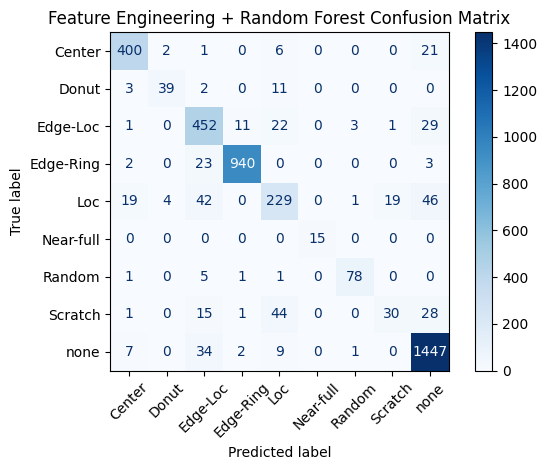

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_confusion_matrix.png


In [28]:
# ============================================================
# 31. Confusion Matrix 시각화 및 저장
# ============================================================

cm = confusion_matrix(y_test_fe, test_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Feature Engineering + Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(RF_CM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion Matrix 저장 완료:", RF_CM_PATH)

In [29]:
# ============================================================
# 32. Feature Importance 계산 및 저장
# ============================================================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df.to_csv(RF_IMPORTANCE_PATH, index=False)

print("Feature Importance 저장 완료:", RF_IMPORTANCE_PATH)

print()
print("상위 20개 Feature:")
display(importance_df.head(20))

Feature Importance 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_feature_importance.csv

상위 20개 Feature:


,feature,importance
0,largest_component_ratio,0.093767
1,defect_ratio,0.063056
2,middle_defect_ratio,0.062397
3,edge_defect_ratio,0.056379
4,distance_from_center_std,0.055483
5,middle_defect_share,0.055159
6,bbox_fill_ratio,0.053854
7,distance_from_center_mean,0.048212
8,defect_count,0.042903
9,center_defect_ratio,0.042025


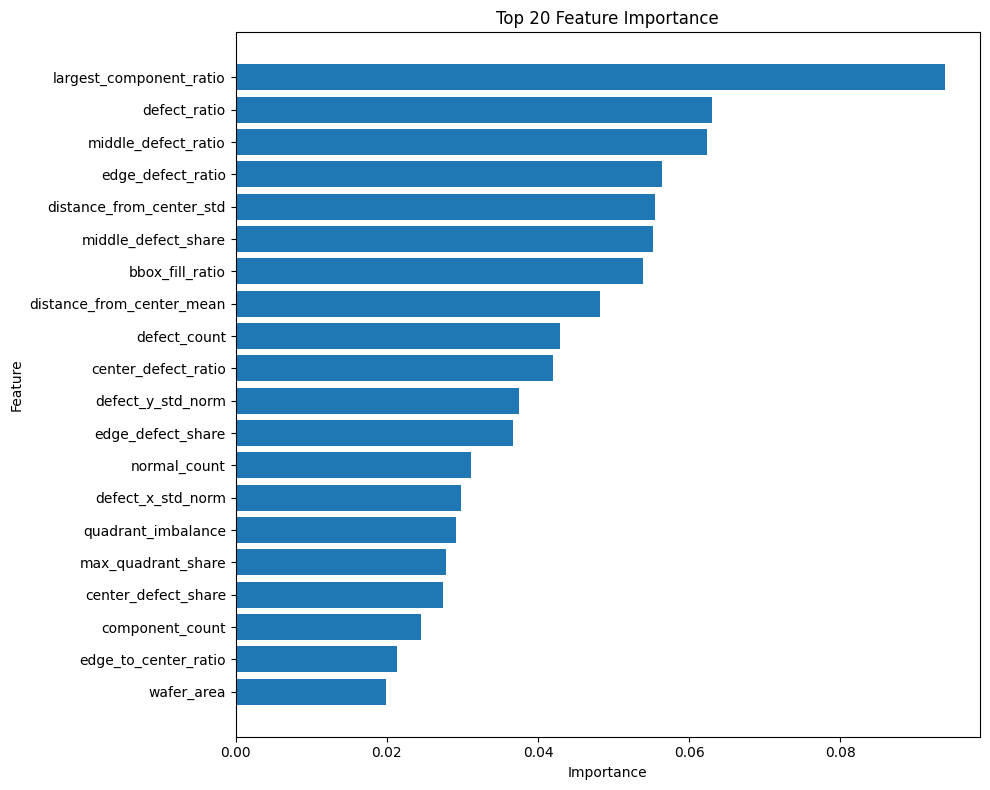

In [30]:
# ============================================================
# 33. Feature Importance 시각화
# ============================================================

top_n = 20

top_importance = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 34. Random Forest 모델 저장
# ============================================================

joblib.dump(rf_model, RF_MODEL_PATH)

print("Random Forest 모델 저장 완료:", RF_MODEL_PATH)

Random Forest 모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_random_forest.pkl


In [34]:
# ============================================================
# 35. CNN 결과와 비교용 표 생성
# ============================================================

cnn_accuracy = 0.9099
cnn_balanced_accuracy = 0.8845
cnn_macro_f1 = 0.8663

comparison_df = pd.DataFrame({
    "model": [
        "Light CNN",
        "Feature Engineering + Random Forest"
    ],
    "input_type": [
        "64 x 64 wafer map image",
        "handcrafted wafer map features"
    ],
    "accuracy": [
        cnn_accuracy,
        test_accuracy
    ],
    "balanced_accuracy": [
        cnn_balanced_accuracy,
        test_balanced_accuracy
    ],
    "macro_f1": [
        cnn_macro_f1,
        test_macro_f1
    ]
})

COMPARISON_PATH = os.path.join(OUTPUT_DIR, "cnn_vs_feature_engineering_comparison.csv")

comparison_df.to_csv(COMPARISON_PATH, index=False)

print("CNN vs Feature Engineering 비교표 저장 완료:", COMPARISON_PATH)

display(comparison_df)

CNN vs Feature Engineering 비교표 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/cnn_vs_feature_engineering_comparison.csv


,model,input_type,accuracy,balanced_accuracy,macro_f1
0,Light CNN,64 x 64 wafer map image,0.909900,0.884500,0.866300
1,Feature Engineering + Random Forest,handcrafted wafer map features,0.895854,0.804573,0.822417


# **Feature Engineering 기반 baseline 모델 비교 추가를 위한 코드**

Baseline 결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models

Feature Engineering + Logistic Regression 학습 시작
Feature Engineering + Logistic Regression 학습 완료
학습 시간: 13.32 초

[Validation 성능]
Accuracy: 0.8499506416584403
Balanced Accuracy: 0.8324579567260781
Macro F1-score: 0.7808611686290337
Weighted F1-score: 0.8576709917008513
Macro Recall: 0.8324579567260781

[Test 성능]
Accuracy: 0.8460019743336624
Balanced Accuracy: 0.8175260304641434
Macro F1-score: 0.7612943832952077
Weighted F1-score: 0.8529113307231367
Macro Recall: 0.8175260304641434

[Test Classification Report]
              precision    recall  f1-score   support

      Center     0.8767    0.9093    0.8927       430
       Donut     0.6026    0.8545    0.7068        55
    Edge-Loc     0.7216    0.7091    0.7153       519
   Edge-Ring     0.9824    0.9236    0.9521       968
         Loc     0.6418    0.5028    0.5639       360
   Near-full     0.8824    1.0000    0.9375        15
 

<Figure size 1000x800 with 0 Axes>

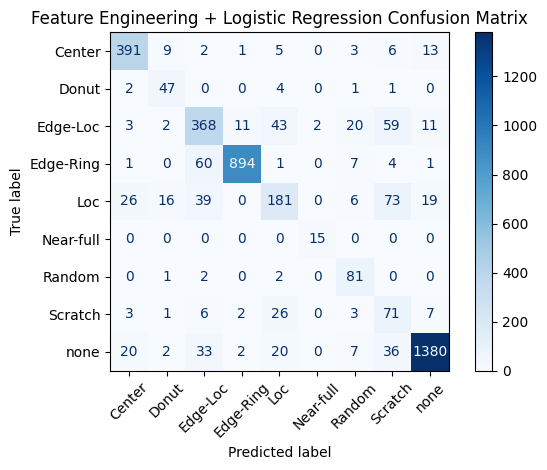

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_logistic_regression_confusion_matrix.png
모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_logistic_regression.pkl

Feature Engineering + Decision Tree 학습 시작
Feature Engineering + Decision Tree 학습 완료
학습 시간: 1.83 초

[Validation 성능]
Accuracy: 0.8262586377097729
Balanced Accuracy: 0.7488156121204622
Macro F1-score: 0.7503882808257659
Weighted F1-score: 0.8270544584082288
Macro Recall: 0.7488156121204622

[Test 성능]
Accuracy: 0.8292201382033564
Balanced Accuracy: 0.7495978602661367
Macro F1-score: 0.750457040473588
Weighted F1-score: 0.8311704798470487
Macro Recall: 0.7495978602661367

[Test Classification Report]
              precision    recall  f1-score   support

      Center     0.8826    0.8744    0.8785       430
       Donut     0.6731    0.6364    0.6542        55
    Edge-Loc    

<Figure size 1000x800 with 0 Axes>

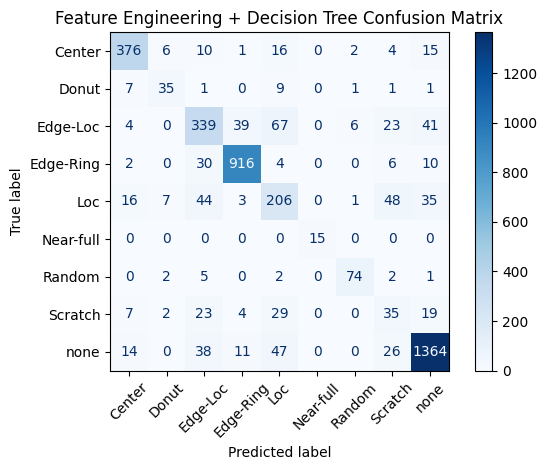

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_decision_tree_confusion_matrix.png
모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_decision_tree.pkl

Feature Engineering + Random Forest 학습 시작
Feature Engineering + Random Forest 학습 완료
학습 시간: 44.1 초

[Validation 성능]
Accuracy: 0.8886969397828233
Balanced Accuracy: 0.8032069132912335
Macro F1-score: 0.8114159992928582
Weighted F1-score: 0.8817124485372082
Macro Recall: 0.8032069132912335

[Test 성능]
Accuracy: 0.8958538993089832
Balanced Accuracy: 0.8045731997071428
Macro F1-score: 0.8224168435536953
Weighted F1-score: 0.8902313149559049
Macro Recall: 0.8045731997071428

[Test Classification Report]
              precision    recall  f1-score   support

      Center     0.9217    0.9302    0.9259       430
       Donut     0.8667    0.7091    0.7800        55
    Edge-Loc     0.7875    

<Figure size 1000x800 with 0 Axes>

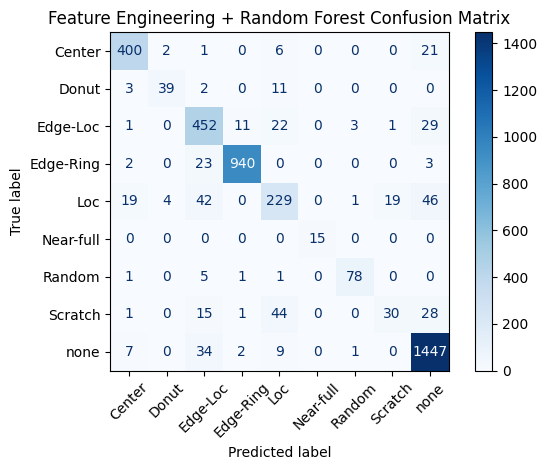

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_random_forest_confusion_matrix.png
모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_random_forest.pkl

Feature Engineering + LinearSVM 학습 시작
Feature Engineering + LinearSVM 학습 완료
학습 시간: 3.86 초

[Validation 성능]
Accuracy: 0.8580947680157947
Balanced Accuracy: 0.7872183168177026
Macro F1-score: 0.7590931079628916
Weighted F1-score: 0.8544932811780251
Macro Recall: 0.7872183168177026

[Test 성능]
Accuracy: 0.8548864758144127
Balanced Accuracy: 0.7777327764541462
Macro F1-score: 0.7385522430772946
Weighted F1-score: 0.851406567537122
Macro Recall: 0.7777327764541462

[Test Classification Report]
              precision    recall  f1-score   support

      Center     0.8720    0.9186    0.8947       430
       Donut     0.5227    0.8364    0.6434        55
    Edge-Loc     0.7217    0.7495   

<Figure size 1000x800 with 0 Axes>

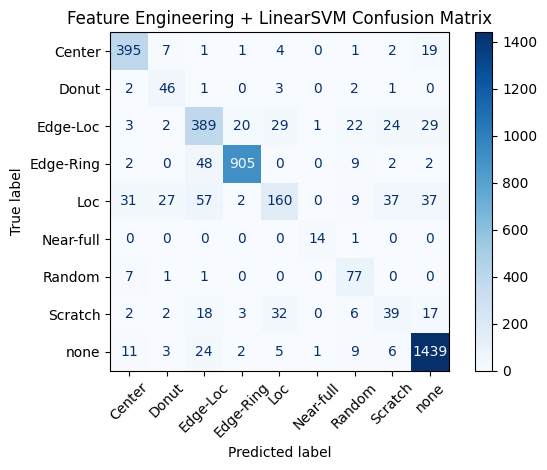

Confusion Matrix 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_linearsvm_confusion_matrix.png
모델 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_plus_linearsvm.pkl

Baseline 모델 성능표 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_baseline_metrics.csv


,model,input_type,train_time_sec,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,Feature Engineering + Random Forest,handcrafted wafer map features,44.101508,0.888697,0.803207,0.811416,0.881712,0.803207,0.895854,0.804573,0.822417,0.890231,0.804573
1,Feature Engineering + Logistic Regression,handcrafted wafer map features,13.316194,0.849951,0.832458,0.780861,0.857671,0.832458,0.846002,0.817526,0.761294,0.852911,0.817526
2,Feature Engineering + Decision Tree,handcrafted wafer map features,1.825254,0.826259,0.748816,0.750388,0.827054,0.748816,0.829220,0.749598,0.750457,0.831170,0.749598
3,Feature Engineering + LinearSVM,handcrafted wafer map features,3.862538,0.858095,0.787218,0.759093,0.854493,0.787218,0.854886,0.777733,0.738552,0.851407,0.777733



Baseline Classification Report 통합 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_baseline_classification_reports.csv


,model,class_or_metric,precision,recall,f1-score,support
0,Feature Engineering + Logistic Regression,Center,0.876682,0.909302,0.892694,430.000000
1,Feature Engineering + Logistic Regression,Donut,0.602564,0.854545,0.706767,55.000000
2,Feature Engineering + Logistic Regression,Edge-Loc,0.721569,0.709056,0.715258,519.000000
3,Feature Engineering + Logistic Regression,Edge-Ring,0.982418,0.923554,0.952077,968.000000
4,Feature Engineering + Logistic Regression,Loc,0.641844,0.502778,0.563863,360.000000
5,Feature Engineering + Logistic Regression,Near-full,0.882353,1.000000,0.937500,15.000000
6,Feature Engineering + Logistic Regression,Random,0.632812,0.941860,0.757009,86.000000
7,Feature Engineering + Logistic Regression,Scratch,0.284000,0.596639,0.384824,119.000000
8,Feature Engineering + Logistic Regression,none,0.964361,0.920000,0.941658,1500.000000
9,Feature Engineering + Logistic Regression,accuracy,0.846002,0.846002,0.846002,0.846002


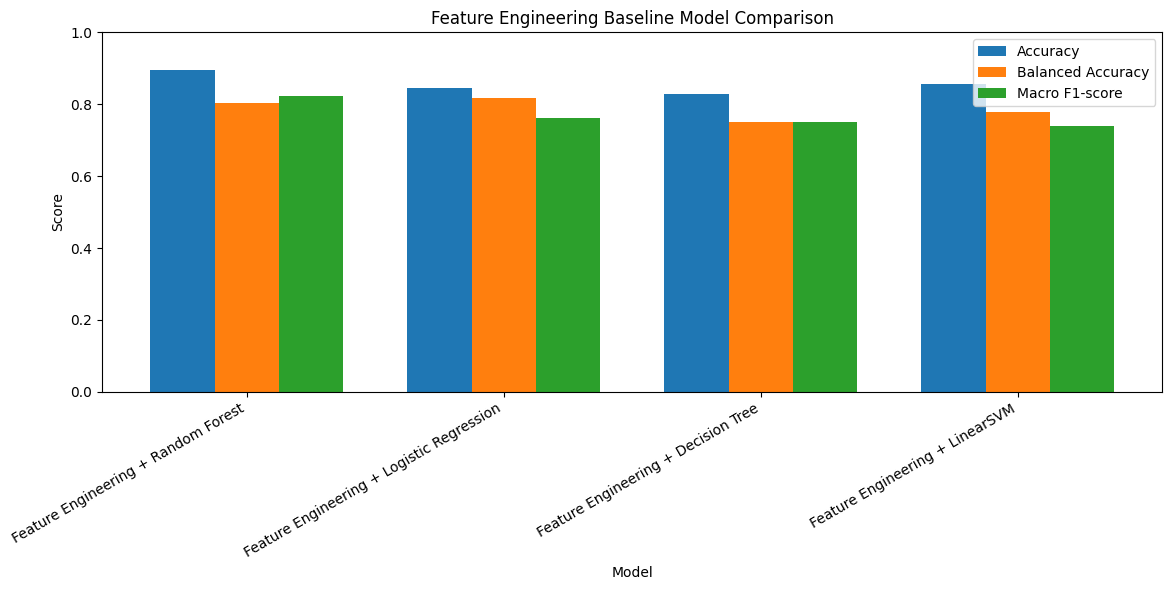

Baseline 모델 비교 그래프 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/feature_engineering_baseline_comparison_bar.png

가장 좋은 Feature Engineering 기반 모델
모델: Feature Engineering + Random Forest
Test Accuracy: 0.8958538993089832
Test Balanced Accuracy: 0.8045731997071428
Test Macro F1-score: 0.8224168435536953

저장된 Light CNN 결과를 불러온다.

CNN vs Feature Engineering Baseline 최종 비교표 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/cnn_vs_feature_baseline_comparison.csv


,model,input_type,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,Light CNN,64 x 64 wafer map image,0.909921,0.884472,0.866305,0.910085,0.884472
1,Feature Engineering + Random Forest,handcrafted wafer map features,0.895854,0.804573,0.822417,0.890231,0.804573
2,Feature Engineering + Logistic Regression,handcrafted wafer map features,0.846002,0.817526,0.761294,0.852911,0.817526
3,Feature Engineering + Decision Tree,handcrafted wafer map features,0.829220,0.749598,0.750457,0.831170,0.749598
4,Feature Engineering + LinearSVM,handcrafted wafer map features,0.854886,0.777733,0.738552,0.851407,0.777733


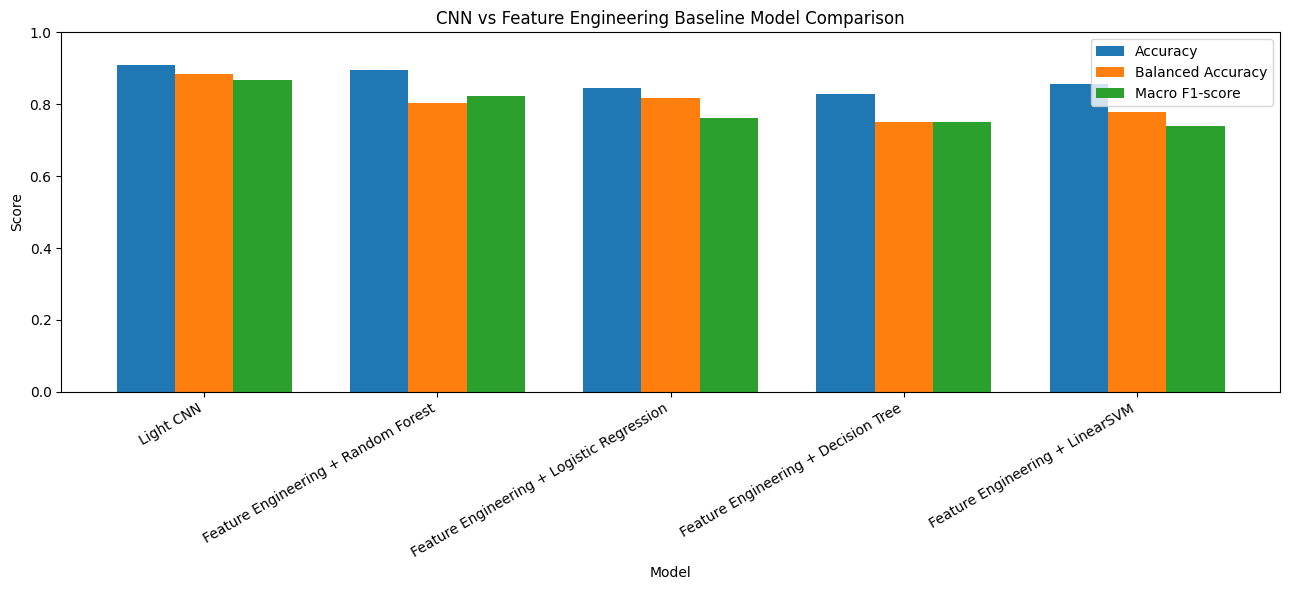

CNN vs Feature Engineering 최종 비교 그래프 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/feature_engineering_baseline_models/cnn_vs_feature_baseline_comparison_bar.png

보고서에 넣을 수 있는 요약
Feature Engineering 기반 baseline 모델 비교 결과, 가장 높은 Macro F1-score를 보인 모델은 Feature Engineering + Random Forest이다. 이는 수작업으로 설계한 위치, 밀도, 외곽 집중도, 형상 feature가 전통적인 머신러닝 모델에서도 결함 패턴 분류에 유의미하게 사용될 수 있음을 보여준다. 또한 Light CNN 결과와 비교함으로써, 이미지 기반 딥러닝 접근과 해석 가능한 feature 기반 접근의 성능 차이를 함께 분석할 수 있었다.


In [35]:
# ============================================================
# 36. Feature Engineering 기반 Baseline 모델 비교
# ============================================================
#
# 이 셀의 목적:
# 기존에는 Feature Engineering 결과를 Random Forest에만 사용했다.
# 하지만 보고서 완성도를 높이기 위해,
# 같은 Feature Table을 여러 전통 머신러닝 모델에 넣고 성능을 비교한다.
#
# 비교 모델:
# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest
# 4. LinearSVM
#
# 이렇게 하면 Random Forest가 단독으로 나온 것이 아니라,
# 여러 baseline 모델 중 하나로 비교되기 때문에 보고서 논리가 자연스러워진다.
#
# ============================================================


# ============================================================
# 36-1. 필요한 라이브러리 추가
# ============================================================

import time
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 36-2. 결과 저장 폴더 설정
# ============================================================

BASELINE_DIR = os.path.join(OUTPUT_DIR, "feature_engineering_baseline_models")
os.makedirs(BASELINE_DIR, exist_ok=True)

BASELINE_METRICS_PATH = os.path.join(
    BASELINE_DIR,
    "feature_engineering_baseline_metrics.csv"
)

BASELINE_REPORT_PATH = os.path.join(
    BASELINE_DIR,
    "feature_engineering_baseline_classification_reports.csv"
)

BASELINE_COMPARISON_FIG_PATH = os.path.join(
    BASELINE_DIR,
    "feature_engineering_baseline_comparison_bar.png"
)

FINAL_COMPARISON_PATH = os.path.join(
    BASELINE_DIR,
    "cnn_vs_feature_baseline_comparison.csv"
)

FINAL_COMPARISON_FIG_PATH = os.path.join(
    BASELINE_DIR,
    "cnn_vs_feature_baseline_comparison_bar.png"
)

print("Baseline 결과 저장 폴더:", BASELINE_DIR)


# ============================================================
# 36-3. 파일 이름 안전하게 만드는 함수
# ============================================================

def make_safe_name(model_name):
    """
    모델 이름에는 공백, +, / 같은 문자가 들어갈 수 있다.
    파일 이름으로 저장할 때 문제가 생기지 않도록 안전한 문자열로 바꾼다.
    """

    safe_name = model_name.lower()
    safe_name = safe_name.replace(" ", "_")
    safe_name = safe_name.replace("+", "plus")
    safe_name = safe_name.replace("/", "_")
    safe_name = safe_name.replace("-", "_")

    return safe_name


# ============================================================
# 36-4. 모델 평가 함수
# ============================================================

def train_and_evaluate_baseline_model(
    model_name,
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
):
    """
    하나의 모델을 학습하고 validation/test 성능을 계산하는 함수이다.

    이 함수를 만든 이유:
    Logistic Regression, Decision Tree, Random Forest, LinearSVM 모두
    학습 -> 예측 -> 성능 계산 -> 결과 저장 과정이 거의 동일하다.

    따라서 같은 코드를 반복해서 쓰지 않고,
    함수 하나로 공통 평가 과정을 처리한다.
    """

    print()
    print("============================================================")
    print(model_name, "학습 시작")
    print("============================================================")

    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    print(model_name, "학습 완료")
    print("학습 시간:", round(train_time, 2), "초")

    # ============================================================
    # Validation 데이터 예측
    # ============================================================

    val_pred = model.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_balanced_accuracy = balanced_accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro")
    val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")
    val_macro_recall = recall_score(y_val, val_pred, average="macro")

    # ============================================================
    # Test 데이터 예측
    # ============================================================

    test_pred = model.predict(X_test)

    test_accuracy = accuracy_score(y_test, test_pred)
    test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
    test_macro_f1 = f1_score(y_test, test_pred, average="macro")
    test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")
    test_macro_recall = recall_score(y_test, test_pred, average="macro")

    print()
    print("[Validation 성능]")
    print("Accuracy:", val_accuracy)
    print("Balanced Accuracy:", val_balanced_accuracy)
    print("Macro F1-score:", val_macro_f1)
    print("Weighted F1-score:", val_weighted_f1)
    print("Macro Recall:", val_macro_recall)

    print()
    print("[Test 성능]")
    print("Accuracy:", test_accuracy)
    print("Balanced Accuracy:", test_balanced_accuracy)
    print("Macro F1-score:", test_macro_f1)
    print("Weighted F1-score:", test_weighted_f1)
    print("Macro Recall:", test_macro_recall)

    print()
    print("[Test Classification Report]")
    print(classification_report(
        y_test,
        test_pred,
        target_names=class_names,
        digits=4
    ))

    # ============================================================
    # 모델별 Classification Report 저장용 DataFrame 생성
    # ============================================================

    report_dict = classification_report(
        y_test,
        test_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df.reset_index()
    report_df = report_df.rename(columns={"index": "class_or_metric"})
    report_df.insert(0, "model", model_name)

    # ============================================================
    # Confusion Matrix 저장
    # ============================================================

    safe_name = make_safe_name(model_name)

    cm = confusion_matrix(y_test, test_pred)

    cm_path = os.path.join(
        BASELINE_DIR,
        safe_name + "_confusion_matrix.png"
    )

    plt.figure(figsize=(10, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        xticks_rotation=45,
        values_format="d"
    )

    plt.title(model_name + " Confusion Matrix")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion Matrix 저장 완료:", cm_path)

    # ============================================================
    # 모델 저장
    # ============================================================

    model_path = os.path.join(
        BASELINE_DIR,
        safe_name + ".pkl"
    )

    joblib.dump(model, model_path)

    print("모델 저장 완료:", model_path)

    # ============================================================
    # 최종 성능 요약 반환
    # ============================================================

    result = {
        "model": model_name,
        "input_type": "handcrafted wafer map features",
        "train_time_sec": train_time,

        "val_accuracy": val_accuracy,
        "val_balanced_accuracy": val_balanced_accuracy,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "val_macro_recall": val_macro_recall,

        "test_accuracy": test_accuracy,
        "test_balanced_accuracy": test_balanced_accuracy,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
        "test_macro_recall": test_macro_recall
    }

    return result, report_df, test_pred


# ============================================================
# 36-5. 비교할 Baseline 모델 정의
# ============================================================
#
# Logistic Regression과 LinearSVM은 feature scale의 영향을 많이 받는다.
# 따라서 StandardScaler를 Pipeline으로 같이 묶어서 사용한다.
#
# Decision Tree와 Random Forest는 tree 기반 모델이라 feature scaling이 필수는 아니다.
#
# ============================================================

baseline_models = {
    "Feature Engineering + Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Feature Engineering + Decision Tree": DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Feature Engineering + Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Feature Engineering + LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000,
            dual=False
        ))
    ])
}


# ============================================================
# 36-6. Baseline 모델 전체 학습 및 평가
# ============================================================

baseline_results = []
baseline_reports = []
baseline_predictions = {}

for model_name, model in baseline_models.items():

    try:
        result, report_df, test_pred = train_and_evaluate_baseline_model(
            model_name=model_name,
            model=model,
            X_train=X_train,
            y_train=y_train_fe,
            X_val=X_val,
            y_val=y_val_fe,
            X_test=X_test,
            y_test=y_test_fe
        )

        baseline_results.append(result)
        baseline_reports.append(report_df)
        baseline_predictions[model_name] = test_pred

    except Exception as e:
        print()
        print("============================================================")
        print(model_name, "실행 중 오류 발생")
        print("오류 내용:", e)
        print("이 모델은 건너뛰고 다음 모델로 진행한다.")
        print("============================================================")


# ============================================================
# 36-7. Baseline 모델 성능표 저장
# ============================================================

baseline_metrics_df = pd.DataFrame(baseline_results)

baseline_metrics_df = baseline_metrics_df.sort_values(
    by="test_macro_f1",
    ascending=False
).reset_index(drop=True)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print()
print("Baseline 모델 성능표 저장 완료:")
print(BASELINE_METRICS_PATH)

display(baseline_metrics_df)


# ============================================================
# 36-8. 모델별 Classification Report 통합 저장
# ============================================================

if len(baseline_reports) > 0:
    all_report_df = pd.concat(baseline_reports, axis=0)

    all_report_df.to_csv(
        BASELINE_REPORT_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print()
    print("Baseline Classification Report 통합 저장 완료:")
    print(BASELINE_REPORT_PATH)

    display(all_report_df.head(20))


# ============================================================
# 36-9. Baseline 모델 성능 비교 그래프
# ============================================================

plot_df = baseline_metrics_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    plot_df["test_accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    plot_df["test_balanced_accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.bar(
    x + width,
    plot_df["test_macro_f1"],
    width,
    label="Macro F1-score"
)

plt.xticks(
    x,
    plot_df["model"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.0)
plt.title("Feature Engineering Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

plt.savefig(
    BASELINE_COMPARISON_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Baseline 모델 비교 그래프 저장 완료:")
print(BASELINE_COMPARISON_FIG_PATH)


# ============================================================
# 36-10. 가장 좋은 Feature Engineering 모델 확인
# ============================================================

best_baseline_row = baseline_metrics_df.iloc[0]

print()
print("============================================================")
print("가장 좋은 Feature Engineering 기반 모델")
print("============================================================")
print("모델:", best_baseline_row["model"])
print("Test Accuracy:", best_baseline_row["test_accuracy"])
print("Test Balanced Accuracy:", best_baseline_row["test_balanced_accuracy"])
print("Test Macro F1-score:", best_baseline_row["test_macro_f1"])


# ============================================================
# 37. Light CNN 결과와 Feature Engineering Baseline 전체 비교
# ============================================================
#
# 기존 CNN 결과는 앞 코드에서 light_cnn_result.csv로 저장했다.
# 만약 해당 CSV가 있으면 거기서 값을 읽고,
# 없으면 기존 보고서에서 사용한 값을 임시로 사용한다.
#
# ============================================================

LIGHT_CNN_RESULT_PATH = os.path.join(OUTPUT_DIR, "light_cnn_result.csv")

if os.path.exists(LIGHT_CNN_RESULT_PATH):
    print()
    print("저장된 Light CNN 결과를 불러온다.")
    cnn_result_df = pd.read_csv(LIGHT_CNN_RESULT_PATH)

    cnn_accuracy = float(cnn_result_df.loc[0, "test_accuracy"])
    cnn_balanced_accuracy = float(cnn_result_df.loc[0, "balanced_accuracy"])
    cnn_macro_f1 = float(cnn_result_df.loc[0, "macro_f1"])
    cnn_weighted_f1 = float(cnn_result_df.loc[0, "weighted_f1"])
    cnn_macro_recall = float(cnn_result_df.loc[0, "macro_recall"])

else:
    print()
    print("Light CNN 결과 CSV가 없어서 기존 기록 값을 사용한다.")

    cnn_accuracy = 0.9099
    cnn_balanced_accuracy = 0.8845
    cnn_macro_f1 = 0.8663
    cnn_weighted_f1 = np.nan
    cnn_macro_recall = np.nan


# ============================================================
# 37-1. 최종 비교표 생성
# ============================================================

cnn_row = pd.DataFrame({
    "model": ["Light CNN"],
    "input_type": ["64 x 64 wafer map image"],
    "test_accuracy": [cnn_accuracy],
    "test_balanced_accuracy": [cnn_balanced_accuracy],
    "test_macro_f1": [cnn_macro_f1],
    "test_weighted_f1": [cnn_weighted_f1],
    "test_macro_recall": [cnn_macro_recall]
})

feature_rows = baseline_metrics_df[[
    "model",
    "input_type",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_macro_recall"
]].copy()

final_comparison_df = pd.concat(
    [cnn_row, feature_rows],
    axis=0
).reset_index(drop=True)

final_comparison_df.to_csv(
    FINAL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print()
print("CNN vs Feature Engineering Baseline 최종 비교표 저장 완료:")
print(FINAL_COMPARISON_PATH)

display(final_comparison_df)


# ============================================================
# 37-2. CNN vs Feature Engineering Baseline 최종 비교 그래프
# ============================================================

plot_df = final_comparison_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(13, 6))

plt.bar(
    x - width,
    plot_df["test_accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    plot_df["test_balanced_accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.bar(
    x + width,
    plot_df["test_macro_f1"],
    width,
    label="Macro F1-score"
)

plt.xticks(
    x,
    plot_df["model"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.0)
plt.title("CNN vs Feature Engineering Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

plt.savefig(
    FINAL_COMPARISON_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("CNN vs Feature Engineering 최종 비교 그래프 저장 완료:")
print(FINAL_COMPARISON_FIG_PATH)


# ============================================================
# 38. 보고서용 요약 문장 출력
# ============================================================

print()
print("============================================================")
print("보고서에 넣을 수 있는 요약")
print("============================================================")

print(
    "Feature Engineering 기반 baseline 모델 비교 결과, "
    f"가장 높은 Macro F1-score를 보인 모델은 {best_baseline_row['model']}이다. "
    "이는 수작업으로 설계한 위치, 밀도, 외곽 집중도, 형상 feature가 "
    "전통적인 머신러닝 모델에서도 결함 패턴 분류에 유의미하게 사용될 수 있음을 보여준다. "
    "또한 Light CNN 결과와 비교함으로써, 이미지 기반 딥러닝 접근과 "
    "해석 가능한 feature 기반 접근의 성능 차이를 함께 분석할 수 있었다."
)

In [36]:
# ============================================================
# 39. ResNet50 경량 실험 준비
# ============================================================
#
# 이 셀의 목적:
# 기존 코드에서 Light CNN과 Feature Engineering baseline 비교까지 완료했으므로,
# 이제 대표 CNN 구조인 ResNet50을 추가로 실험한다.
#
# ResNet50은 Light CNN보다 훨씬 무거운 모델이므로,
# Colab RAM/GPU 메모리 부담을 줄이기 위해 다음과 같이 설정한다.
#
# 1. 입력 크기: 기존과 동일하게 64 x 64 사용
# 2. grayscale wafer map을 3-channel 이미지로 변환
# 3. ResNet50의 convolution base는 freeze
# 4. Dense classifier 부분만 우선 학습
# 5. batch size는 Light CNN보다 작게 설정
#
# ============================================================


# ============================================================
# 39-1. TensorFlow 세션 및 RAM 정리
# ============================================================

import gc
import os
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 이전 TensorFlow 모델이 메모리에 남아 있을 수 있으므로 세션을 정리한다.
tf.keras.backend.clear_session()
gc.collect()

print("TensorFlow 세션 및 RAM 정리 완료")


# ============================================================
# 39-2. ResNet50 실험 설정
# ============================================================

RESNET_IMG_SIZE = IMG_SIZE

# ResNet50은 Light CNN보다 무겁기 때문에 batch size를 작게 둔다.
# RAM 또는 GPU 메모리 부족이 발생하면 16 -> 8로 줄이면 된다.
RESNET_BATCH_SIZE = 16

# 처음에는 짧게 5~10 epoch 정도만 학습해서 동작 여부와 성능을 확인한다.
RESNET_EPOCHS = 10

# 결과 저장 폴더
RESNET_DIR = os.path.join(OUTPUT_DIR, "resnet50_light_experiment")
os.makedirs(RESNET_DIR, exist_ok=True)

RESNET_BEST_MODEL_PATH = os.path.join(RESNET_DIR, "best_resnet50_light.keras")
RESNET_FINAL_MODEL_PATH = os.path.join(RESNET_DIR, "final_resnet50_light.keras")
RESNET_RESULT_PATH = os.path.join(RESNET_DIR, "resnet50_result.csv")
RESNET_REPORT_PATH = os.path.join(RESNET_DIR, "resnet50_classification_report.csv")
RESNET_CM_PATH = os.path.join(RESNET_DIR, "resnet50_confusion_matrix.png")
RESNET_HISTORY_PATH = os.path.join(RESNET_DIR, "resnet50_training_history.csv")
RESNET_CURVE_PATH = os.path.join(RESNET_DIR, "resnet50_training_curve.png")

print("ResNet50 결과 저장 폴더:", RESNET_DIR)
print("ResNet50 batch size:", RESNET_BATCH_SIZE)
print("ResNet50 epochs:", RESNET_EPOCHS)

TensorFlow 세션 및 RAM 정리 완료
ResNet50 결과 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment
ResNet50 batch size: 16
ResNet50 epochs: 10


In [37]:
# ============================================================
# 39-3. ResNet50 입력용 wafer map 전처리 함수
# ============================================================
#
# 기존 Light CNN은 1-channel grayscale 입력을 사용했다.
# 하지만 ResNet50은 기본적으로 RGB 3-channel 이미지를 입력으로 받는다.
#
# 따라서 wafer map을 다음과 같이 변환한다.
#
# 원본 waferMap 값:
# 0: wafer 바깥 또는 빈 영역
# 1: 정상 die
# 2: 불량 die
#
# 변환 과정:
# 1. numpy array 변환
# 2. channel 차원 추가
# 3. 64 x 64로 resize
# 4. 0, 1, 2 값을 0, 127.5, 255 범위로 변환
# 5. 1-channel을 3-channel로 복사
# 6. ResNet50 preprocess_input 적용
#
# ============================================================

def resize_wafer_map_for_resnet50(wafer_map, img_size=RESNET_IMG_SIZE):
    """
    waferMap 하나를 ResNet50 입력 형태인 64 x 64 x 3 이미지로 변환한다.
    """

    # wafer map을 float32 배열로 변환한다.
    wafer_map = np.array(wafer_map, dtype=np.float32)

    # TensorFlow resize를 사용하기 위해 channel 차원을 추가한다.
    wafer_map = np.expand_dims(wafer_map, axis=-1)

    # 원본 wafer map 크기가 서로 다르므로 64 x 64로 통일한다.
    # wafer map은 범주형 값에 가까우므로 nearest 방식을 사용한다.
    wafer_map = tf.image.resize(
        wafer_map,
        size=(img_size, img_size),
        method="nearest"
    )

    # 원래 값은 0, 1, 2이므로 0~255 범위로 맞춘다.
    # 0 -> 0
    # 1 -> 127.5
    # 2 -> 255
    wafer_map = wafer_map / 2.0 * 255.0

    # ResNet50은 3-channel 입력을 요구하므로 grayscale 이미지를 3번 복사한다.
    wafer_map = tf.repeat(wafer_map, repeats=3, axis=-1)

    # ImageNet 사전학습 ResNet50에 맞는 전처리를 적용한다.
    wafer_map = preprocess_input(wafer_map)

    return wafer_map

In [38]:
# ============================================================
# 39-4. ResNet50용 generator 함수
# ============================================================

def wafer_generator_resnet50(index_array):
    """
    ResNet50 학습을 위해 index_array에 해당하는 waferMap과 label을 하나씩 생성한다.

    기존 Light CNN과 마찬가지로,
    전체 이미지를 한 번에 X 배열로 만들지 않고 필요할 때마다 하나씩 처리한다.
    """

    for idx in index_array:
        wafer_map = df_sampled.loc[idx, "waferMap"]
        label = df_sampled.loc[idx, "label_encoded"]

        image = resize_wafer_map_for_resnet50(wafer_map)

        yield image, np.int32(label)


# ============================================================
# 39-5. ResNet50용 tf.data Dataset 생성 함수
# ============================================================

def make_resnet50_dataset(index_array, shuffle=False):
    """
    ResNet50 입력 형태에 맞는 TensorFlow Dataset을 만든다.
    """

    dataset = tf.data.Dataset.from_generator(
        lambda: wafer_generator_resnet50(index_array),
        output_signature=(
            tf.TensorSpec(
                shape=(RESNET_IMG_SIZE, RESNET_IMG_SIZE, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=2048,
            seed=RANDOM_STATE
        )

    dataset = dataset.batch(RESNET_BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


resnet_train_ds = make_resnet50_dataset(train_idx, shuffle=True)
resnet_val_ds = make_resnet50_dataset(val_idx, shuffle=False)
resnet_test_ds = make_resnet50_dataset(test_idx, shuffle=False)

print("ResNet50용 tf.data Dataset 생성 완료")

print("train 개수:", len(train_idx))
print("validation 개수:", len(val_idx))
print("test 개수:", len(test_idx))

ResNet50용 tf.data Dataset 생성 완료
train 개수: 32415
validation 개수: 4052
test 개수: 4052


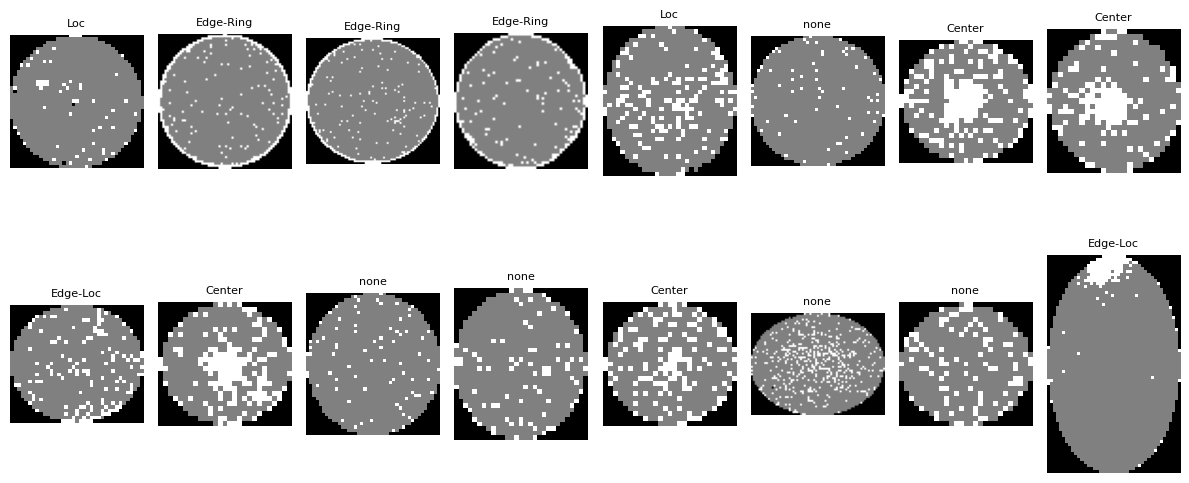

ResNet50 입력용 원본 wafer map 샘플 확인 완료


In [39]:
# ============================================================
# 39-6. ResNet50 입력 샘플 확인
# ============================================================
#
# preprocess_input이 적용된 이미지는 사람이 보기에는 색이 이상하게 보일 수 있다.
# 따라서 여기서는 원래 wafer map 형태를 확인하기 위해,
# df_sampled에서 직접 waferMap을 꺼내 시각화한다.
#
# 이 셀은 필수 학습 코드는 아니지만,
# 데이터가 정상적으로 연결되어 있는지 확인하기 위한 셀이다.
#
# ============================================================

plt.figure(figsize=(12, 6))

sample_indices = train_idx[:16]

for i, idx in enumerate(sample_indices):
    wafer_map = np.array(df_sampled.loc[idx, "waferMap"])
    label = df_sampled.loc[idx, "label"]

    plt.subplot(2, 8, i + 1)
    plt.imshow(wafer_map, cmap="gray")
    plt.title(label, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("ResNet50 입력용 원본 wafer map 샘플 확인 완료")

In [40]:
# ============================================================
# 39-7. ResNet50 모델 생성 함수
# ============================================================
#
# include_top=False:
# ImageNet용 1000개 클래스 분류기를 제거하고,
# feature extractor 부분만 사용한다.
#
# base_model.trainable = False:
# ResNet50 전체를 학습시키면 너무 무겁기 때문에,
# convolution base는 고정하고 뒤쪽 Dense 분류기만 학습한다.
#
# ============================================================

def build_resnet50_light_model(
    input_shape=(RESNET_IMG_SIZE, RESNET_IMG_SIZE, 3),
    num_classes=num_classes
):
    """
    Colab 환경에서 비교적 가볍게 돌릴 수 있도록 구성한 ResNet50 모델이다.
    """

    # ------------------------------------------------------------
    # ImageNet 사전학습 가중치를 먼저 시도한다.
    # 만약 다운로드 오류나 환경 문제가 발생하면 weights=None으로 다시 만든다.
    # ------------------------------------------------------------

    try:
        base_model = ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

        weight_source = "imagenet"

        print("ResNet50 ImageNet 사전학습 가중치 로드 성공")

    except Exception as e:
        print("ResNet50 ImageNet 가중치 로드 실패")
        print("오류 내용:", e)
        print("weights=None으로 ResNet50을 생성한다.")

        base_model = ResNet50(
            include_top=False,
            weights=None,
            input_shape=input_shape
        )

        weight_source = "none"

    # ResNet50 base는 우선 freeze한다.
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_light_transfer"
    )

    return model, weight_source


resnet_model, resnet_weight_source = build_resnet50_light_model()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

print("ResNet50 weight source:", resnet_weight_source)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 ImageNet 사전학습 가중치 로드 성공


Model: "ResNet50_light_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,657 (90.99 MB)

 Trainable params: 263,689 (1.01 MB)

 Non-trainable params: 23,587,968 (89.98 MB)

ResNet50 weight source: imagenet


In [41]:
# ============================================================
# 39-7. ResNet50 모델 생성 함수
# ============================================================
#
# include_top=False:
# ImageNet용 1000개 클래스 분류기를 제거하고,
# feature extractor 부분만 사용한다.
#
# base_model.trainable = False:
# ResNet50 전체를 학습시키면 너무 무겁기 때문에,
# convolution base는 고정하고 뒤쪽 Dense 분류기만 학습한다.
#
# ============================================================

def build_resnet50_light_model(
    input_shape=(RESNET_IMG_SIZE, RESNET_IMG_SIZE, 3),
    num_classes=num_classes
):
    """
    Colab 환경에서 비교적 가볍게 돌릴 수 있도록 구성한 ResNet50 모델이다.
    """

    # ------------------------------------------------------------
    # ImageNet 사전학습 가중치를 먼저 시도한다.
    # 만약 다운로드 오류나 환경 문제가 발생하면 weights=None으로 다시 만든다.
    # ------------------------------------------------------------

    try:
        base_model = ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

        weight_source = "imagenet"

        print("ResNet50 ImageNet 사전학습 가중치 로드 성공")

    except Exception as e:
        print("ResNet50 ImageNet 가중치 로드 실패")
        print("오류 내용:", e)
        print("weights=None으로 ResNet50을 생성한다.")

        base_model = ResNet50(
            include_top=False,
            weights=None,
            input_shape=input_shape
        )

        weight_source = "none"

    # ResNet50 base는 우선 freeze한다.
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_light_transfer"
    )

    return model, weight_source


resnet_model, resnet_weight_source = build_resnet50_light_model()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

print("ResNet50 weight source:", resnet_weight_source)

ResNet50 ImageNet 사전학습 가중치 로드 성공


Model: "ResNet50_light_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,657 (90.99 MB)

 Trainable params: 263,689 (1.01 MB)

 Non-trainable params: 23,587,968 (89.98 MB)

ResNet50 weight source: imagenet


In [43]:
# ============================================================
# 39-7-1. ResNet50 학습용 class_weight_dict 재생성
# ============================================================
#
# ResNet50 학습 셀에서 class_weight_dict를 사용한다.
# 그런데 Colab 런타임 상태에 따라 기존 Light CNN 파트에서 만든
# class_weight_dict 변수가 메모리에서 사라졌을 수 있다.
#
# 따라서 ResNet50 학습 전에 train_idx 기준으로 class_weight_dict를 다시 만든다.
#
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# train 데이터에 해당하는 label만 가져온다.
resnet_train_labels = df_sampled.loc[train_idx, "label_encoded"].values

# train 데이터에 존재하는 클래스 기준으로 class weight를 계산한다.
resnet_class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(resnet_train_labels),
    y=resnet_train_labels
)

# Keras model.fit()에서 사용할 수 있는 dictionary 형태로 변환한다.
class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        np.unique(resnet_train_labels),
        resnet_class_weights_array
    )
}

print("ResNet50 학습용 class_weight_dict 재생성 완료")
print(class_weight_dict)

ResNet50 학습용 class_weight_dict 재생성 완료
{0: 1.0485201358563805, 1: 8.111861861861861, 2: 0.867662410664097, 3: 0.4650912534435262, 4: 1.2531895151936905, 5: 30.26610644257703, 6: 5.197210197210198, 7: 3.7713787085514836, 8: 0.3001388888888889}


In [44]:
# ============================================================
# 39-8. ResNet50 callback 설정
# ============================================================

resnet_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath=RESNET_BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


# ============================================================
# 39-9. ResNet50 모델 학습
# ============================================================

print()
print("============================================================")
print("ResNet50 경량 실험 학습 시작")
print("============================================================")

resnet_start_time = time.time()

resnet_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=RESNET_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=resnet_callbacks
)

resnet_train_time = time.time() - resnet_start_time

print()
print("ResNet50 학습 완료")
print("학습 시간:", round(resnet_train_time, 2), "초")


ResNet50 경량 실험 학습 시작
Epoch 1/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 294s 131ms/step - accuracy: 0.6173 - loss: 0.9681 - val_accuracy: 0.7019 - val_loss: 0.8238 - learning_rate: 0.0010
Epoch 2/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 265s 124ms/step - accuracy: 0.6760 - loss: 0.7781 - val_accuracy: 0.7004 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 3/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 265s 125ms/step - accuracy: 0.6922 - loss: 0.7280 - val_accuracy: 0.6261 - val_loss: 0.9830 - learning_rate: 0.0010
Epoch 4/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 264s 124ms/step - accuracy: 0.7084 - loss: 0.6803 - val_accuracy: 0.7453 - val_loss: 0.7090 - learning_rate: 5.0000e-04
Epoch 5/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 262s 123ms/step - accuracy: 0.7183 - loss: 0.6508 - val_accuracy: 0.7599 - val_loss: 0.6646 - learning_rate: 5.0000e-04
Epoch 6/10
2026/2026 ━━━━━━━━━━━━━━━━━━━━ 259s 122ms/step - accuracy: 0.7217 - loss: 0.6412 - val_accuracy: 0.7357 - val_loss: 0.7150 - learning_rate: 5.0000e-04
Epoch 7/10
2026/20

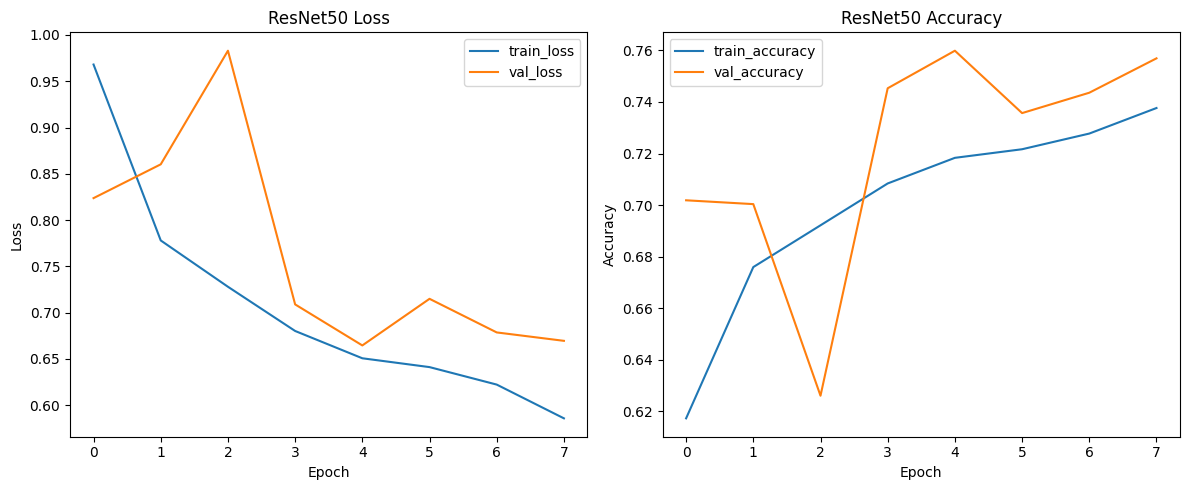

ResNet50 학습 곡선 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/resnet50_training_curve.png


In [45]:
# ============================================================
# 39-10. ResNet50 학습 곡선 시각화 및 저장
# ============================================================

resnet_history_df = pd.DataFrame(resnet_history.history)
resnet_history_df.to_csv(
    RESNET_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resnet_history.history["loss"], label="train_loss")
plt.plot(resnet_history.history["val_loss"], label="val_loss")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnet_history.history["accuracy"], label="train_accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="val_accuracy")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(
    RESNET_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("ResNet50 학습 곡선 저장 완료:")
print(RESNET_CURVE_PATH)

In [46]:
# ============================================================
# 39-11. ResNet50 test 데이터 평가
# ============================================================

resnet_test_loss, resnet_test_acc_from_keras = resnet_model.evaluate(
    resnet_test_ds
)

print()
print("ResNet50 Test Loss:", resnet_test_loss)
print("ResNet50 Test Accuracy from Keras:", resnet_test_acc_from_keras)


# ============================================================
# 39-12. ResNet50 y_true, y_pred 생성
# ============================================================

resnet_y_true = []
resnet_y_pred = []

for batch_images, batch_labels in resnet_test_ds:
    pred_probs = resnet_model.predict(batch_images, verbose=0)

    pred_probs = np.array(pred_probs)
    pred_labels = np.argmax(pred_probs, axis=-1)

    resnet_y_true.extend(batch_labels.numpy().reshape(-1))
    resnet_y_pred.extend(pred_labels.reshape(-1))

resnet_y_true = np.array(resnet_y_true)
resnet_y_pred = np.array(resnet_y_pred)

print("ResNet50 예측 완료")
print("resnet_y_true shape:", resnet_y_true.shape)
print("resnet_y_pred shape:", resnet_y_pred.shape)


# ============================================================
# 39-13. ResNet50 성능 지표 계산
# ============================================================

resnet_accuracy = accuracy_score(resnet_y_true, resnet_y_pred)
resnet_balanced_accuracy = balanced_accuracy_score(resnet_y_true, resnet_y_pred)
resnet_macro_f1 = f1_score(resnet_y_true, resnet_y_pred, average="macro")
resnet_weighted_f1 = f1_score(resnet_y_true, resnet_y_pred, average="weighted")
resnet_macro_recall = recall_score(resnet_y_true, resnet_y_pred, average="macro")

print()
print("============================================================")
print("ResNet50 Test 성능")
print("============================================================")
print("Accuracy:", resnet_accuracy)
print("Balanced Accuracy:", resnet_balanced_accuracy)
print("Macro F1-score:", resnet_macro_f1)
print("Weighted F1-score:", resnet_weighted_f1)
print("Macro Recall:", resnet_macro_recall)

print()
print("ResNet50 Classification Report:")
print(classification_report(
    resnet_y_true,
    resnet_y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

254/254 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.7549 - loss: 0.6776

ResNet50 Test Loss: 0.6775678992271423
ResNet50 Test Accuracy from Keras: 0.7549358606338501
ResNet50 예측 완료
resnet_y_true shape: (4052,)
resnet_y_pred shape: (4052,)

ResNet50 Test 성능
Accuracy: 0.7549358341559723
Balanced Accuracy: 0.7707359604418622
Macro F1-score: 0.6867169226636205
Weighted F1-score: 0.7686823121601315
Macro Recall: 0.7707359604418622

ResNet50 Classification Report:
              precision    recall  f1-score   support

      Center     0.8838    0.7605    0.8175       430
       Donut     0.5102    0.9091    0.6536        55
    Edge-Loc     0.5625    0.5549    0.5587       519
   Edge-Ring     0.9793    0.9277    0.9528       968
         Loc     0.5013    0.5500    0.5245       360
   Near-full     0.5000    1.0000    0.6667        15
      Random     0.8621    0.8721    0.8671        86
     Scratch     0.2353    0.6050    0.3388       119
        none     0.8497    0.7573    0.8008 

In [47]:
# ============================================================
# 39-14. ResNet50 결과 저장
# ============================================================

resnet_result_dict = {
    "model": "ResNet50 light transfer",
    "input_type": "64 x 64 wafer map image, 3-channel",
    "img_size": RESNET_IMG_SIZE,
    "batch_size": RESNET_BATCH_SIZE,
    "epochs": RESNET_EPOCHS,
    "none_limit": NONE_LIMIT,
    "num_classes": num_classes,
    "class_names": class_names,
    "weight_source": resnet_weight_source,
    "base_model_trainable": False,
    "train_time_sec": resnet_train_time,
    "test_accuracy": resnet_accuracy,
    "test_balanced_accuracy": resnet_balanced_accuracy,
    "test_macro_f1": resnet_macro_f1,
    "test_weighted_f1": resnet_weighted_f1,
    "test_macro_recall": resnet_macro_recall
}

resnet_result_df = pd.DataFrame([resnet_result_dict])

resnet_result_df.to_csv(
    RESNET_RESULT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("ResNet50 결과 저장 완료:")
print(RESNET_RESULT_PATH)

display(resnet_result_df)


# ============================================================
# 39-15. ResNet50 Classification Report 저장
# ============================================================

resnet_report_dict = classification_report(
    resnet_y_true,
    resnet_y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True,
    zero_division=0
)

resnet_report_df = pd.DataFrame(resnet_report_dict).transpose()

resnet_report_df.to_csv(
    RESNET_REPORT_PATH,
    encoding="utf-8-sig"
)

print("ResNet50 Classification Report 저장 완료:")
print(RESNET_REPORT_PATH)

display(resnet_report_df)

ResNet50 결과 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/resnet50_result.csv


,model,input_type,img_size,batch_size,epochs,none_limit,num_classes,class_names,weight_source,base_model_trainable,train_time_sec,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,ResNet50 light transfer,"64 x 64 wafer map image, 3-channel",64,16,10,15000,9,"[Center, Donut, Edge-Loc, Edge-Ring, Loc, Near...",imagenet,False,2118.223281,0.754936,0.770736,0.686717,0.768682,0.770736


ResNet50 Classification Report 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/resnet50_classification_report.csv


,precision,recall,f1-score,support
Center,0.883784,0.760465,0.817500,430.000000
Donut,0.510204,0.909091,0.653595,55.000000
Edge-Loc,0.562500,0.554913,0.558681,519.000000
Edge-Ring,0.979280,0.927686,0.952785,968.000000
Loc,0.501266,0.550000,0.524503,360.000000
Near-full,0.500000,1.000000,0.666667,15.000000
Random,0.862069,0.872093,0.867052,86.000000
Scratch,0.235294,0.605042,0.338824,119.000000
none,0.849663,0.757333,0.800846,1500.000000
accuracy,0.754936,0.754936,0.754936,0.754936


<Figure size 1000x800 with 0 Axes>

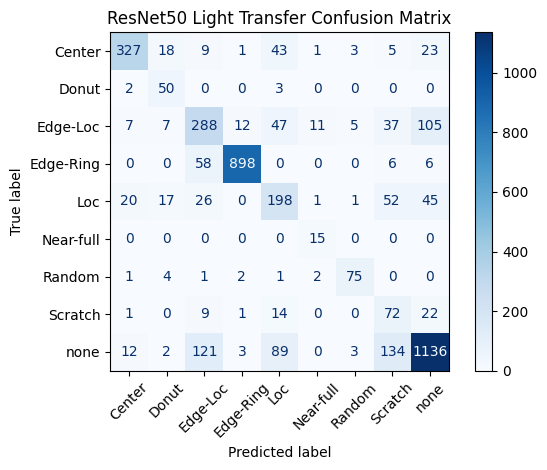

ResNet50 Confusion Matrix 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/resnet50_confusion_matrix.png


In [48]:
# ============================================================
# 39-16. ResNet50 Confusion Matrix 시각화 및 저장
# ============================================================

resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=resnet_cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("ResNet50 Light Transfer Confusion Matrix")
plt.tight_layout()

plt.savefig(
    RESNET_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ResNet50 Confusion Matrix 저장 완료:")
print(RESNET_CM_PATH)

In [49]:
# ============================================================
# 39-17. ResNet50 최종 모델 저장
# ============================================================

resnet_model.save(RESNET_FINAL_MODEL_PATH)

print("ResNet50 최종 모델 저장 완료:")
print(RESNET_FINAL_MODEL_PATH)


# ============================================================
# 39-18. ResNet50 실험 이후 RAM 정리
# ============================================================

gc.collect()

print("ResNet50 경량 실험 전체 완료")

ResNet50 최종 모델 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/final_resnet50_light.keras
ResNet50 경량 실험 전체 완료


In [50]:
# ============================================================
# 40. Light CNN vs ResNet50 vs Feature Engineering 최종 비교
# ============================================================
#
# 이 셀의 목적:
# 기존 코드에서 만든 Light CNN 결과,
# 새로 만든 ResNet50 결과,
# Feature Engineering baseline 모델 비교 결과를 하나의 표로 합친다.
#
# 보고서에서는 이 표를 통해 다음 비교가 가능하다.
#
# 1. 직접 설계한 Light CNN
# 2. 대표 CNN 구조인 ResNet50
# 3. 수작업 feature 기반 전통 머신러닝 모델들
#
# ============================================================


# ============================================================
# 40-1. 최종 비교 결과 저장 경로 설정
# ============================================================

FINAL_RESNET_COMPARISON_PATH = os.path.join(
    RESNET_DIR,
    "light_cnn_resnet50_feature_engineering_all_comparison.csv"
)

FINAL_RESNET_COMPARISON_FIG_PATH = os.path.join(
    RESNET_DIR,
    "light_cnn_resnet50_feature_engineering_all_comparison_bar.png"
)

REPORT_CORE_COMPARISON_PATH = os.path.join(
    RESNET_DIR,
    "report_core_model_comparison.csv"
)

REPORT_CORE_COMPARISON_FIG_PATH = os.path.join(
    RESNET_DIR,
    "report_core_model_comparison_bar.png"
)


# ============================================================
# 40-2. Light CNN 결과 불러오기
# ============================================================

LIGHT_CNN_RESULT_PATH = os.path.join(OUTPUT_DIR, "light_cnn_result.csv")

if os.path.exists(LIGHT_CNN_RESULT_PATH):
    print("저장된 Light CNN 결과를 불러온다.")

    cnn_result_df = pd.read_csv(LIGHT_CNN_RESULT_PATH)

    light_cnn_accuracy = float(cnn_result_df.loc[0, "test_accuracy"])
    light_cnn_balanced_accuracy = float(cnn_result_df.loc[0, "balanced_accuracy"])
    light_cnn_macro_f1 = float(cnn_result_df.loc[0, "macro_f1"])
    light_cnn_weighted_f1 = float(cnn_result_df.loc[0, "weighted_f1"])
    light_cnn_macro_recall = float(cnn_result_df.loc[0, "macro_recall"])

else:
    print("Light CNN 결과 CSV가 없어서 기존 보고서 기록 값을 사용한다.")

    light_cnn_accuracy = 0.9099
    light_cnn_balanced_accuracy = 0.8845
    light_cnn_macro_f1 = 0.8663
    light_cnn_weighted_f1 = np.nan
    light_cnn_macro_recall = np.nan


light_cnn_row = pd.DataFrame({
    "model": ["Light CNN"],
    "input_type": ["64 x 64 grayscale wafer map image"],
    "test_accuracy": [light_cnn_accuracy],
    "test_balanced_accuracy": [light_cnn_balanced_accuracy],
    "test_macro_f1": [light_cnn_macro_f1],
    "test_weighted_f1": [light_cnn_weighted_f1],
    "test_macro_recall": [light_cnn_macro_recall]
})


# ============================================================
# 40-3. ResNet50 결과 불러오기
# ============================================================

if os.path.exists(RESNET_RESULT_PATH):
    print("저장된 ResNet50 결과를 불러온다.")

    loaded_resnet_result_df = pd.read_csv(RESNET_RESULT_PATH)

    resnet_row = pd.DataFrame({
        "model": ["ResNet50"],
        "input_type": ["64 x 64 wafer map image, 3-channel"],
        "test_accuracy": [float(loaded_resnet_result_df.loc[0, "test_accuracy"])],
        "test_balanced_accuracy": [float(loaded_resnet_result_df.loc[0, "test_balanced_accuracy"])],
        "test_macro_f1": [float(loaded_resnet_result_df.loc[0, "test_macro_f1"])],
        "test_weighted_f1": [float(loaded_resnet_result_df.loc[0, "test_weighted_f1"])],
        "test_macro_recall": [float(loaded_resnet_result_df.loc[0, "test_macro_recall"])]
    })

else:
    print("ResNet50 결과 CSV가 없어서 현재 변수 값을 사용한다.")

    resnet_row = pd.DataFrame({
        "model": ["ResNet50"],
        "input_type": ["64 x 64 wafer map image, 3-channel"],
        "test_accuracy": [resnet_accuracy],
        "test_balanced_accuracy": [resnet_balanced_accuracy],
        "test_macro_f1": [resnet_macro_f1],
        "test_weighted_f1": [resnet_weighted_f1],
        "test_macro_recall": [resnet_macro_recall]
    })


# ============================================================
# 40-4. Feature Engineering baseline 결과 준비
# ============================================================

# 기존 코드에서 baseline_metrics_df가 메모리에 남아 있으면 그대로 사용한다.
# 만약 런타임 상황에 따라 변수가 없으면 저장된 CSV에서 다시 불러온다.

if "baseline_metrics_df" in globals():
    print("메모리에 있는 baseline_metrics_df를 사용한다.")

    feature_baseline_df = baseline_metrics_df.copy()

else:
    print("baseline_metrics_df가 메모리에 없어서 CSV에서 불러온다.")

    BASELINE_METRICS_PATH = os.path.join(
        OUTPUT_DIR,
        "feature_engineering_baseline_models",
        "feature_engineering_baseline_metrics.csv"
    )

    feature_baseline_df = pd.read_csv(BASELINE_METRICS_PATH)


feature_rows_for_final = feature_baseline_df[[
    "model",
    "input_type",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_macro_recall"
]].copy()


# ============================================================
# 40-5. 전체 모델 비교표 생성
# ============================================================

all_model_comparison_df = pd.concat(
    [
        light_cnn_row,
        resnet_row,
        feature_rows_for_final
    ],
    axis=0
).reset_index(drop=True)

all_model_comparison_df = all_model_comparison_df.sort_values(
    by="test_macro_f1",
    ascending=False
).reset_index(drop=True)

all_model_comparison_df.to_csv(
    FINAL_RESNET_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print()
print("Light CNN + ResNet50 + Feature Engineering 전체 비교표 저장 완료:")
print(FINAL_RESNET_COMPARISON_PATH)

display(all_model_comparison_df)

저장된 Light CNN 결과를 불러온다.
저장된 ResNet50 결과를 불러온다.
메모리에 있는 baseline_metrics_df를 사용한다.

Light CNN + ResNet50 + Feature Engineering 전체 비교표 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/light_cnn_resnet50_feature_engineering_all_comparison.csv


,model,input_type,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,Light CNN,64 x 64 grayscale wafer map image,0.909921,0.884472,0.866305,0.910085,0.884472
1,Feature Engineering + Random Forest,handcrafted wafer map features,0.895854,0.804573,0.822417,0.890231,0.804573
2,Feature Engineering + Logistic Regression,handcrafted wafer map features,0.846002,0.817526,0.761294,0.852911,0.817526
3,Feature Engineering + Decision Tree,handcrafted wafer map features,0.829220,0.749598,0.750457,0.831170,0.749598
4,Feature Engineering + LinearSVM,handcrafted wafer map features,0.854886,0.777733,0.738552,0.851407,0.777733
5,ResNet50,"64 x 64 wafer map image, 3-channel",0.754936,0.770736,0.686717,0.768682,0.770736


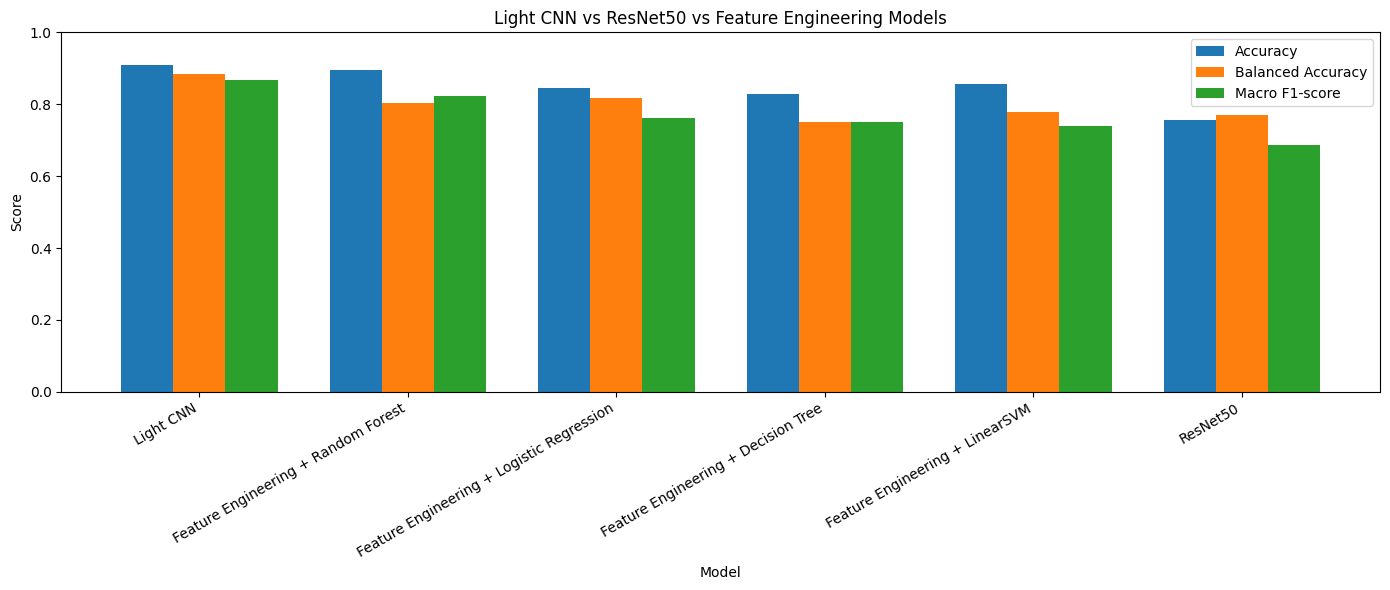

전체 모델 비교 그래프 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/light_cnn_resnet50_feature_engineering_all_comparison_bar.png


In [51]:
# ============================================================
# 40-6. 전체 모델 비교 그래프 생성 및 저장
# ============================================================

plot_df = all_model_comparison_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(
    x - width,
    plot_df["test_accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    plot_df["test_balanced_accuracy"],
    width,
    label="Balanced Accuracy"
)

plt.bar(
    x + width,
    plot_df["test_macro_f1"],
    width,
    label="Macro F1-score"
)

plt.xticks(
    x,
    plot_df["model"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.0)
plt.title("Light CNN vs ResNet50 vs Feature Engineering Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

plt.savefig(
    FINAL_RESNET_COMPARISON_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("전체 모델 비교 그래프 저장 완료:")
print(FINAL_RESNET_COMPARISON_FIG_PATH)

In [52]:
# ============================================================
# 40-7. 보고서용 핵심 모델 비교표 생성
# ============================================================
#
# 전체 비교표에는 Feature Engineering baseline 모델이 여러 개 들어간다.
# 하지만 보고서 본문에는 너무 많은 모델을 한 번에 넣기보다,
# 대표 모델 3개를 비교하는 표가 더 깔끔하다.
#
# 대표 비교:
# 1. Light CNN
# 2. ResNet50
# 3. Feature Engineering 기반 최고 성능 모델
#
# ============================================================

best_feature_row = feature_rows_for_final.sort_values(
    by="test_macro_f1",
    ascending=False
).iloc[[0]].copy()

report_core_comparison_df = pd.concat(
    [
        light_cnn_row,
        resnet_row,
        best_feature_row
    ],
    axis=0
).reset_index(drop=True)

report_core_comparison_df = report_core_comparison_df.sort_values(
    by="test_macro_f1",
    ascending=False
).reset_index(drop=True)

report_core_comparison_df.to_csv(
    REPORT_CORE_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("보고서용 핵심 모델 비교표 저장 완료:")
print(REPORT_CORE_COMPARISON_PATH)

display(report_core_comparison_df)

보고서용 핵심 모델 비교표 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/resnet50_light_experiment/report_core_model_comparison.csv


,model,input_type,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall
0,Light CNN,64 x 64 grayscale wafer map image,0.909921,0.884472,0.866305,0.910085,0.884472
1,Feature Engineering + Random Forest,handcrafted wafer map features,0.895854,0.804573,0.822417,0.890231,0.804573
2,ResNet50,"64 x 64 wafer map image, 3-channel",0.754936,0.770736,0.686717,0.768682,0.770736


In [61]:
# ============================================================
# 41. 자동 품질 분석 리포트 기본 설정
# ============================================================
#
# 이 셀은 네 현재 코드 구조에 맞춘 버전이다.
#
# 중요한 점:
# 1. test_df를 사용하지 않는다.
# 2. df_sampled + test_idx 구조를 그대로 사용한다.
# 3. Light CNN은 model 변수를 믿지 않고 저장된 keras 파일에서 다시 불러온다.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

# ============================================================
# 41-1. 자동 리포트 결과 저장 폴더
# ============================================================

REPORT_SAVE_DIR = os.path.join(OUTPUT_DIR, "report_figures")
os.makedirs(REPORT_SAVE_DIR, exist_ok=True)

print("자동 리포트 저장 폴더:", REPORT_SAVE_DIR)


# ============================================================
# 41-2. 필수 변수 확인
# ============================================================
# 네 코드에서는 아래 변수들이 이미 존재해야 한다.
#
# df_sampled       : 전체 샘플링된 wafer map 데이터
# test_idx         : test set index 배열
# class_names      : label encoder 기준 클래스 이름
# feature_cols     : Feature Engineering에 사용한 feature 목록
# extract_wafer_features : waferMap 하나에서 feature를 뽑는 함수
# ============================================================

required_vars = [
    "df_sampled",
    "test_idx",
    "class_names",
    "label_encoder",
    "feature_cols",
    "extract_wafer_features",
    "OUTPUT_DIR",
    "IMG_SIZE"
]

for var_name in required_vars:
    if var_name not in globals():
        raise NameError(f"{var_name} 변수가 없습니다. 앞쪽 코드를 먼저 실행해야 합니다.")

print("필수 변수 확인 완료")

print("df_sampled shape:", df_sampled.shape)
print("test sample 수:", len(test_idx))
print("class_names:", class_names)


# ============================================================
# 41-3. Light CNN 모델 다시 불러오기
# ============================================================
# 뒤쪽 코드에서 model 변수가 다른 모델로 바뀌었을 가능성이 있으므로,
# 저장된 Light CNN 모델 파일을 다시 불러온다.
# ============================================================

FINAL_LIGHT_CNN_PATH = os.path.join(OUTPUT_DIR, "final_light_cnn.keras")
BEST_LIGHT_CNN_PATH = os.path.join(OUTPUT_DIR, "best_light_cnn.keras")

if os.path.exists(FINAL_LIGHT_CNN_PATH):
    LIGHT_CNN_MODEL = tf.keras.models.load_model(FINAL_LIGHT_CNN_PATH)
    print("final_light_cnn.keras 로드 완료:")
    print(FINAL_LIGHT_CNN_PATH)

elif os.path.exists(BEST_LIGHT_CNN_PATH):
    LIGHT_CNN_MODEL = tf.keras.models.load_model(BEST_LIGHT_CNN_PATH)
    print("best_light_cnn.keras 로드 완료:")
    print(BEST_LIGHT_CNN_PATH)

else:
    raise FileNotFoundError(
        "final_light_cnn.keras 또는 best_light_cnn.keras 파일을 찾지 못했습니다. "
        "Light CNN 학습 셀을 먼저 실행해야 합니다."
    )


# ============================================================
# 41-4. Random Forest 모델 준비
# ============================================================
# 네 코드에서는 rf_model 변수가 이미 존재할 가능성이 높다.
# 만약 런타임에서 사라졌으면 저장된 pkl 파일에서 다시 불러온다.
# ============================================================

if "rf_model" in globals():
    RF_MODEL_FOR_REPORT = rf_model
    print("메모리에 있는 rf_model 사용")

elif "RF_MODEL_PATH" in globals() and os.path.exists(RF_MODEL_PATH):
    RF_MODEL_FOR_REPORT = joblib.load(RF_MODEL_PATH)
    print("저장된 Random Forest 모델 로드 완료:")
    print(RF_MODEL_PATH)

else:
    RF_MODEL_FOR_REPORT = None
    print("Random Forest 모델을 찾지 못했습니다. RF 예측은 생략합니다.")


# ============================================================
# 41-5. 자동 리포트 대상 클래스 설정
# ============================================================
# 보고서 13번 예시는 Edge-Ring이 가장 자연스럽다.
# ============================================================

TARGET_CLASS = "Edge-Ring"

print("자동 리포트 대상 클래스:", TARGET_CLASS)

자동 리포트 저장 폴더: /content/drive/MyDrive/ML Project/WM811K/outputs/report_figures
필수 변수 확인 완료
df_sampled shape: (40519, 8)
test sample 수: 4052
class_names: [np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]
final_light_cnn.keras 로드 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/final_light_cnn.keras
메모리에 있는 rf_model 사용
자동 리포트 대상 클래스: Edge-Ring


In [64]:
# ============================================================
# 42. Light CNN 예측 함수
# ============================================================
#
# 오류 원인:
# 기존 노트북의 15번 셀에 resize_wafer_map 함수가 있었지만,
# 현재 런타임에서 그 셀이 실행되지 않아 NameError가 발생했다.
#
# 해결:
# 자동 리포트 코드 안에서 Light CNN용 resize 함수를 다시 정의한다.
# ============================================================

def resize_wafer_map_for_lightcnn(wafer_map, img_size=IMG_SIZE):
    """
    waferMap 하나를 Light CNN 입력 형태로 변환한다.

    원본 waferMap 값:
    0: wafer 바깥 또는 빈 영역
    1: 정상 die
    2: 불량 die

    처리 과정:
    1. numpy array로 변환
    2. channel 차원 추가
    3. 64 x 64로 resize
    4. 0~2 값을 0~1 범위로 정규화
    """

    wafer_map = np.array(wafer_map, dtype=np.float32)

    # Light CNN은 64 x 64 x 1 형태의 입력을 사용한다.
    wafer_map = np.expand_dims(wafer_map, axis=-1)

    wafer_map = tf.image.resize(
        wafer_map,
        size=(img_size, img_size),
        method="nearest"
    )

    # 원래 값이 0, 1, 2이므로 2로 나누어 0~1 범위로 맞춘다.
    wafer_map = wafer_map / 2.0

    return wafer_map


def predict_light_cnn_one_sample(wafer_map):
    """
    wafer map 하나를 Light CNN에 넣고 예측 결과를 반환한다.

    반환값:
    - pred_label: 예측 클래스 이름
    - confidence: 가장 높은 softmax 확률
    - top3: Top-3 예측 결과
    - probs: 전체 클래스 확률
    """

    # 위에서 새로 정의한 Light CNN 전용 resize 함수를 사용한다.
    image = resize_wafer_map_for_lightcnn(
        wafer_map,
        img_size=IMG_SIZE
    )

    # TensorFlow Tensor일 수 있으므로 numpy 배열로 변환한다.
    image = np.array(image, dtype=np.float32)

    # 모델 입력 shape 확인
    # Light CNN이면 보통 (None, 64, 64, 1)이다.
    expected_channels = LIGHT_CNN_MODEL.input_shape[-1]

    # 혹시 모델 입력이 3채널이면 1채널 이미지를 3채널로 복사한다.
    # 현재 Light CNN은 보통 1채널이므로 대부분 실행되지 않는다.
    if expected_channels == 3 and image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)

    # batch 차원 추가
    image = np.expand_dims(image, axis=0)

    probs = LIGHT_CNN_MODEL.predict(image, verbose=0)[0]

    top3_idx = np.argsort(probs)[::-1][:3]

    top3 = []

    for idx in top3_idx:
        top3.append({
            "class": class_names[int(idx)],
            "prob": float(probs[int(idx)])
        })

    pred_idx = int(top3_idx[0])
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_label, confidence, top3, probs


def label_to_text(label_value):
    """
    label 값이 숫자면 class_names 기준으로 문자 라벨로 바꾼다.
    이미 문자열이면 그대로 반환한다.
    """

    if isinstance(label_value, (int, np.integer)):
        return class_names[int(label_value)]

    return str(label_value)


print("Light CNN 예측 함수 재정의 완료")
print("Light CNN input shape:", LIGHT_CNN_MODEL.input_shape)

Light CNN 예측 함수 재정의 완료
Light CNN input shape: (None, 64, 64, 1)


In [65]:
# ============================================================
# 43. Edge-Ring Test Sample 자동 선택
# ============================================================
#
# 목표:
# test_idx 안에서 실제 라벨이 Edge-Ring인 샘플을 찾고,
# 그중 Light CNN이 Edge-Ring으로 맞게 예측한 샘플을 선택한다.
#
# 여러 개가 있으면 confidence가 가장 높은 샘플을 사용한다.
# ============================================================

def select_edge_ring_test_sample():
    """
    test set에서 Edge-Ring 샘플을 찾고,
    Light CNN이 Edge-Ring으로 맞게 예측한 샘플 중 confidence가 높은 것을 선택한다.
    """

    # ------------------------------------------------------------
    # 1. test_idx 안에서 실제 라벨이 Edge-Ring인 후보 찾기
    # ------------------------------------------------------------

    edge_ring_candidates = []

    for idx in test_idx:
        true_label = df_sampled.loc[idx, "label"]

        if str(true_label) == TARGET_CLASS:
            edge_ring_candidates.append(idx)

    print(f"test set 안의 {TARGET_CLASS} 후보 개수:", len(edge_ring_candidates))

    if len(edge_ring_candidates) == 0:
        raise ValueError(f"test set에서 {TARGET_CLASS} 샘플을 찾지 못했습니다.")


    # ------------------------------------------------------------
    # 2. 후보 중 CNN이 Edge-Ring으로 맞게 예측한 샘플 찾기
    # ------------------------------------------------------------

    best_result = None
    best_confidence = -1

    for idx in edge_ring_candidates:
        wafer_map = df_sampled.loc[idx, "waferMap"]
        true_label = df_sampled.loc[idx, "label"]

        pred_label, confidence, top3, probs = predict_light_cnn_one_sample(wafer_map)

        if pred_label == TARGET_CLASS:
            if confidence > best_confidence:
                best_confidence = confidence
                best_result = {
                    "sample_idx": idx,
                    "wafer_map": wafer_map,
                    "true_label": true_label,
                    "cnn_pred_label": pred_label,
                    "cnn_confidence": confidence,
                    "cnn_top3": top3,
                    "cnn_probs": probs
                }


    # ------------------------------------------------------------
    # 3. 만약 맞게 예측한 샘플이 없다면 첫 번째 Edge-Ring 샘플 사용
    # ------------------------------------------------------------

    if best_result is None:
        print("주의: CNN이 Edge-Ring으로 맞게 예측한 샘플을 찾지 못했습니다.")
        print("대신 첫 번째 Edge-Ring test sample을 사용합니다.")

        idx = edge_ring_candidates[0]
        wafer_map = df_sampled.loc[idx, "waferMap"]
        true_label = df_sampled.loc[idx, "label"]

        pred_label, confidence, top3, probs = predict_light_cnn_one_sample(wafer_map)

        best_result = {
            "sample_idx": idx,
            "wafer_map": wafer_map,
            "true_label": true_label,
            "cnn_pred_label": pred_label,
            "cnn_confidence": confidence,
            "cnn_top3": top3,
            "cnn_probs": probs
        }

    return best_result


# ============================================================
# 선택 실행
# ============================================================

selected = select_edge_ring_test_sample()

sample_idx = selected["sample_idx"]
sample_wafer_map = selected["wafer_map"]
true_label = selected["true_label"]
cnn_pred_label = selected["cnn_pred_label"]
cnn_confidence = selected["cnn_confidence"]
cnn_top3 = selected["cnn_top3"]

print()
print("============================================================")
print("자동 리포트에 사용할 Test Sample")
print("============================================================")
print("sample index:", sample_idx)
print("실제 라벨:", true_label)
print("Light CNN 예측 라벨:", cnn_pred_label)
print("Light CNN confidence:", f"{cnn_confidence * 100:.2f}%")

print()
print("Top-3 예측 결과")
for rank, item in enumerate(cnn_top3, start=1):
    print(f"{rank}순위: {item['class']} / {item['prob'] * 100:.2f}%")


test set 안의 Edge-Ring 후보 개수: 968

자동 리포트에 사용할 Test Sample
sample index: 31806
실제 라벨: Edge-Ring
Light CNN 예측 라벨: Edge-Ring
Light CNN confidence: 100.00%

Top-3 예측 결과
1순위: Edge-Ring / 100.00%
2순위: Edge-Loc / 0.00%
3순위: Scratch / 0.00%


In [66]:
# ============================================================
# 44. 선택 샘플 Feature 계산 + Random Forest 예측
# ============================================================

# ============================================================
# 44-1. 선택된 wafer map에서 feature 추출
# ============================================================

sample_features_dict = extract_wafer_features(sample_wafer_map)

sample_features_df = pd.DataFrame([sample_features_dict])

# Random Forest가 학습할 때 사용한 feature_cols 순서와 동일하게 맞춘다.
sample_X_for_rf = sample_features_df.reindex(columns=feature_cols, fill_value=0)

print("선택 샘플 Feature shape:", sample_X_for_rf.shape)


# ============================================================
# 44-2. Random Forest 예측
# ============================================================

if RF_MODEL_FOR_REPORT is not None:
    rf_pred_encoded = RF_MODEL_FOR_REPORT.predict(sample_X_for_rf)[0]
    rf_pred_label = label_to_text(rf_pred_encoded)
else:
    rf_pred_label = "Random Forest 예측 생략"

print("Random Forest 예측 라벨:", rf_pred_label)


# ============================================================
# 44-3. 보고서에 넣을 주요 feature만 정리
# ============================================================

important_feature_names = [
    "defect_ratio",
    "center_defect_ratio",
    "middle_defect_ratio",
    "edge_defect_ratio",
    "edge_to_center_ratio",
    "distance_from_center_mean",
    "edge_defect_share",
    "center_defect_share",
    "bbox_width_norm",
    "bbox_height_norm",
    "aspect_ratio",
    "component_count",
    "linearity_score"
]

important_feature_rows = []

for feature_name in important_feature_names:
    if feature_name in sample_features_dict:
        important_feature_rows.append({
            "feature": feature_name,
            "value": sample_features_dict[feature_name]
        })

important_feature_df = pd.DataFrame(important_feature_rows)

display(important_feature_df)

# 저장
IMPORTANT_FEATURE_CSV_PATH = os.path.join(
    REPORT_SAVE_DIR,
    "edge_ring_sample_important_features.csv"
)

important_feature_df.to_csv(
    IMPORTANT_FEATURE_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("주요 feature 저장 완료:")
print(IMPORTANT_FEATURE_CSV_PATH)

선택 샘플 Feature shape: (1, 34)
Random Forest 예측 라벨: Edge-Ring


,feature,value
0,defect_ratio,0.093271
1,center_defect_ratio,0.030414
2,middle_defect_ratio,0.018700
3,edge_defect_ratio,0.201868
4,edge_to_center_ratio,17.237288
5,distance_from_center_mean,0.789457
6,edge_defect_share,0.860288
7,center_defect_share,0.049111
8,bbox_width_norm,1.000000
9,bbox_height_norm,1.000000


주요 feature 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/report_figures/edge_ring_sample_important_features.csv


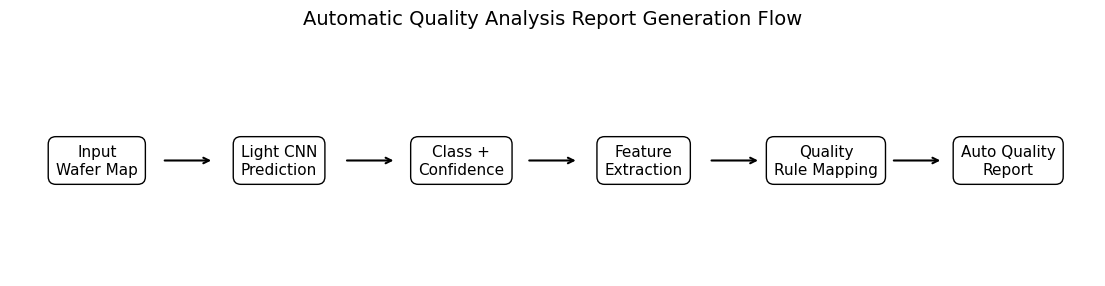

그림 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/report_figures/fig19_auto_quality_report_flowchart.png


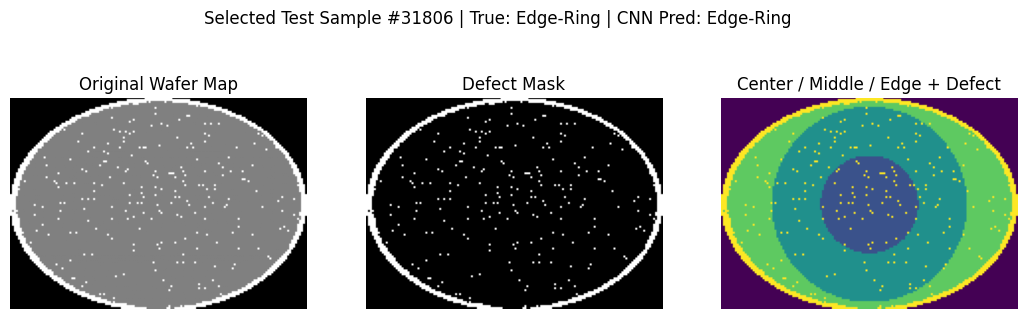

그림 저장 완료: /content/drive/MyDrive/ML Project/WM811K/outputs/report_figures/fig20_selected_edge_ring_test_sample.png


In [67]:
# ============================================================
# 45. 보고서용 그림 생성
# ============================================================
#
# 생성되는 그림:
# [그림 19. 자동 품질 분석 리포트 생성 흐름도]
# [그림 20. 자동 품질 분석 리포트 예시에 사용한 Test Wafer Map]
# ============================================================

# ============================================================
# 45-1. [그림 19] 자동 품질 분석 리포트 생성 흐름도
# ============================================================

def save_auto_report_flowchart():
    """
    보고서용 자동 리포트 생성 흐름도 저장
    한글 깨짐을 피하기 위해 그림 내부 텍스트는 영어로 작성한다.
    """

    steps = [
        "Input\nWafer Map",
        "Light CNN\nPrediction",
        "Class +\nConfidence",
        "Feature\nExtraction",
        "Quality\nRule Mapping",
        "Auto Quality\nReport"
    ]

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.axis("off")

    x_positions = np.linspace(0.08, 0.92, len(steps))
    y = 0.5

    for i, step in enumerate(steps):
        x = x_positions[i]

        ax.text(
            x,
            y,
            step,
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(
                boxstyle="round,pad=0.5",
                edgecolor="black",
                facecolor="white"
            )
        )

        if i < len(steps) - 1:
            ax.annotate(
                "",
                xy=(x_positions[i + 1] - 0.06, y),
                xytext=(x + 0.06, y),
                arrowprops=dict(arrowstyle="->", lw=1.5)
            )

    ax.set_title(
        "Automatic Quality Analysis Report Generation Flow",
        fontsize=14,
        pad=15
    )

    save_path = os.path.join(
        REPORT_SAVE_DIR,
        "fig19_auto_quality_report_flowchart.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("그림 저장 완료:", save_path)


save_auto_report_flowchart()


# ============================================================
# 45-2. [그림 20] 선택된 Test Wafer Map 시각화
# ============================================================

def make_center_middle_edge_map(wafer_map):
    """
    wafer map을 center / middle / edge 영역으로 나누어 표시하기 위한 배열 생성
    """

    wafer = np.array(wafer_map)

    wafer_mask = wafer > 0
    defect_mask = wafer == 2

    height, width = wafer.shape

    wafer_y, wafer_x = np.where(wafer_mask)

    center_y = np.mean(wafer_y)
    center_x = np.mean(wafer_x)

    yy, xx = np.indices(wafer.shape)

    wafer_dist = np.sqrt((wafer_y - center_y) ** 2 + (wafer_x - center_x) ** 2)
    max_radius = np.max(wafer_dist)

    all_dist = np.sqrt((yy - center_y) ** 2 + (xx - center_x) ** 2)
    all_dist_norm = all_dist / max_radius

    region_map = np.zeros_like(wafer, dtype=float)

    # center / middle / edge 표시
    region_map[wafer_mask & (all_dist_norm <= 0.33)] = 1
    region_map[wafer_mask & (all_dist_norm > 0.33) & (all_dist_norm <= 0.66)] = 2
    region_map[wafer_mask & (all_dist_norm > 0.66)] = 3

    # defect는 더 높은 값으로 표시
    region_map[defect_mask] = 4

    return region_map


def save_selected_wafer_map_figure():
    """
    선택된 wafer map, defect mask, center/middle/edge 영역을 함께 저장한다.
    """

    wafer = np.array(sample_wafer_map)
    defect_mask = (wafer == 2).astype(int)
    region_map = make_center_middle_edge_map(sample_wafer_map)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(wafer, cmap="gray")
    axes[0].set_title("Original Wafer Map")
    axes[0].axis("off")

    axes[1].imshow(defect_mask, cmap="gray")
    axes[1].set_title("Defect Mask")
    axes[1].axis("off")

    axes[2].imshow(region_map)
    axes[2].set_title("Center / Middle / Edge + Defect")
    axes[2].axis("off")

    fig.suptitle(
        f"Selected Test Sample #{sample_idx} | True: {true_label} | CNN Pred: {cnn_pred_label}",
        fontsize=12
    )

    save_path = os.path.join(
        REPORT_SAVE_DIR,
        "fig20_selected_edge_ring_test_sample.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("그림 저장 완료:", save_path)


save_selected_wafer_map_figure()

In [68]:
# ============================================================
# 46. 자동 품질 분석 리포트 표와 문장 생성
# ============================================================

def to_percent(x):
    return f"{x * 100:.2f}%"


top3_text = " / ".join([
    f"{rank}순위 {item['class']}: {item['prob'] * 100:.2f}%"
    for rank, item in enumerate(cnn_top3, start=1)
])


# ============================================================
# 46-1. 보고서 표 생성
# ============================================================

auto_report_table = pd.DataFrame([
    ["입력 샘플", f"Test sample #{sample_idx}"],
    ["실제 라벨", str(true_label)],
    ["Light CNN 예측 라벨", str(cnn_pred_label)],
    ["Light CNN confidence", to_percent(cnn_confidence)],
    ["Top-3 예측 결과", top3_text],
    ["Random Forest 예측 라벨", str(rf_pred_label)],

    ["defect_ratio", f"{sample_features_dict['defect_ratio']:.4f}"],
    ["center_defect_ratio", f"{sample_features_dict['center_defect_ratio']:.4f}"],
    ["middle_defect_ratio", f"{sample_features_dict['middle_defect_ratio']:.4f}"],
    ["edge_defect_ratio", f"{sample_features_dict['edge_defect_ratio']:.4f}"],
    ["edge_to_center_ratio", f"{sample_features_dict['edge_to_center_ratio']:.4f}"],
    ["distance_from_center_mean", f"{sample_features_dict['distance_from_center_mean']:.4f}"],
], columns=["항목", "결과"])

display(auto_report_table)

AUTO_REPORT_TABLE_PATH = os.path.join(
    REPORT_SAVE_DIR,
    "table9_edge_ring_auto_quality_report.csv"
)

auto_report_table.to_csv(
    AUTO_REPORT_TABLE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("자동 리포트 표 저장 완료:")
print(AUTO_REPORT_TABLE_PATH)


# ============================================================
# 46-2. 보고서 13번에 넣을 시나리오형 문장 생성
# ============================================================

scenario_report_text = f"""
반도체 엔지니어 A는 생산이 완료된 wafer lot의 품질 상태를 확인하던 중, 특정 wafer map에서 외곽부에 결함이 집중된 듯한 패턴을 확인하였다. 기존 방식이라면 엔지니어가 wafer map 이미지를 직접 확인하고 결함의 위치와 형태를 판단해야 하지만, 본 프로젝트에서 구축한 자동 품질 분석 시스템은 wafer map 이미지를 입력받아 결함 유형과 품질 분석 관점의 해석을 함께 제공한다.

선택된 test sample의 실제 라벨은 {true_label}이며, Light CNN 모델은 해당 wafer map을 {cnn_pred_label} 패턴으로 예측하였다. 이때 모델의 예측 confidence는 {cnn_confidence * 100:.2f}%로 나타났다. Top-3 예측 결과는 {top3_text} 순으로 나타났다.

Feature Engineering 결과를 함께 확인하면, 전체 wafer 영역 중 결함 die가 차지하는 defect_ratio는 {sample_features_dict['defect_ratio']:.4f}로 계산되었다. 중심부 결함 비율인 center_defect_ratio는 {sample_features_dict['center_defect_ratio']:.4f}, 중간부 결함 비율인 middle_defect_ratio는 {sample_features_dict['middle_defect_ratio']:.4f}, 외곽부 결함 비율인 edge_defect_ratio는 {sample_features_dict['edge_defect_ratio']:.4f}로 나타났다. 또한 외곽부 결함과 중심부 결함의 상대적인 차이를 나타내는 edge_to_center_ratio는 {sample_features_dict['edge_to_center_ratio']:.4f}로 계산되었다.

이 결과는 결함이 wafer 중심부보다 외곽부에 상대적으로 더 많이 분포하고 있음을 의미한다. 따라서 해당 wafer map은 단순히 결함 개수가 많은 샘플이라기보다는, 결함이 wafer edge 주변에 집중되는 Edge-Ring 계열의 패턴으로 해석할 수 있다. 즉, Light CNN의 이미지 기반 예측 결과와 Feature Engineering 기반 수치 feature가 같은 방향의 해석을 제공한 사례라고 볼 수 있다.

품질 분석 관점에서 Edge-Ring 패턴은 외곽부 공정 균일도 문제, edge bead, edge exclusion 조건, edge handling 문제와 관련될 가능성이 있다. 따라서 실제 제조 현장에서 이와 같은 패턴이 반복적으로 관찰된다면 외곽부 막 두께 radial profile, edge exclusion 영역 검사 결과, 해당 lot의 장비 recipe 변경 이력, 동일 lot 내 다른 wafer map 패턴을 추가로 확인할 필요가 있다.

단, WM-811K 데이터셋에는 실제 장비 로그, 공정 recipe, lot 이력, 계측 데이터가 포함되어 있지 않다. 따라서 본 자동 품질 분석 리포트는 실제 공정 원인을 확정하는 도구가 아니라, wafer map 패턴과 feature 값을 기반으로 추가 확인이 필요한 공정 원인 후보를 제시하는 도구로 해석해야 한다.
""".strip()

print()
print("=" * 80)
print("보고서 13번에 넣을 시나리오형 자동 리포트 문장")
print("=" * 80)
print(scenario_report_text)


SCENARIO_REPORT_TEXT_PATH = os.path.join(
    REPORT_SAVE_DIR,
    "edge_ring_scenario_auto_quality_report_text.txt"
)

with open(SCENARIO_REPORT_TEXT_PATH, "w", encoding="utf-8-sig") as f:
    f.write(scenario_report_text)

print()
print("시나리오형 자동 리포트 문장 저장 완료:")
print(SCENARIO_REPORT_TEXT_PATH)


# ============================================================
# 46-3. 최종 결과물 경로 정리
# ============================================================

print()
print("=" * 80)
print("보고서에 넣을 결과물 정리")
print("=" * 80)

print("[그림 19. 자동 품질 분석 리포트 생성 흐름도]")
print(os.path.join(REPORT_SAVE_DIR, "fig19_auto_quality_report_flowchart.png"))

print()
print("[그림 20. 자동 품질 분석 리포트 예시에 사용한 Test Wafer Map]")
print(os.path.join(REPORT_SAVE_DIR, "fig20_selected_edge_ring_test_sample.png"))

print()
print("[표 9. Edge-Ring Test Sample 자동 품질 분석 리포트 예시]")
print(AUTO_REPORT_TABLE_PATH)

print()
print("[보고서 13번 시나리오형 본문]")
print(SCENARIO_REPORT_TEXT_PATH)

,항목,결과
0,입력 샘플,Test sample #31806
1,실제 라벨,Edge-Ring
2,Light CNN 예측 라벨,Edge-Ring
3,Light CNN confidence,100.00%
4,Top-3 예측 결과,1순위 Edge-Ring: 100.00% / 2순위 Edge-Loc: 0.00% /...
5,Random Forest 예측 라벨,Edge-Ring
6,defect_ratio,0.0933
7,center_defect_ratio,0.0304
8,middle_defect_ratio,0.0187
9,edge_defect_ratio,0.2019


자동 리포트 표 저장 완료:
/content/drive/MyDrive/ML Project/WM811K/outputs/report_figures/table9_edge_ring_auto_quality_report.csv

보고서 13번에 넣을 시나리오형 자동 리포트 문장
반도체 엔지니어 A는 생산이 완료된 wafer lot의 품질 상태를 확인하던 중, 특정 wafer map에서 외곽부에 결함이 집중된 듯한 패턴을 확인하였다. 기존 방식이라면 엔지니어가 wafer map 이미지를 직접 확인하고 결함의 위치와 형태를 판단해야 하지만, 본 프로젝트에서 구축한 자동 품질 분석 시스템은 wafer map 이미지를 입력받아 결함 유형과 품질 분석 관점의 해석을 함께 제공한다.

선택된 test sample의 실제 라벨은 Edge-Ring이며, Light CNN 모델은 해당 wafer map을 Edge-Ring 패턴으로 예측하였다. 이때 모델의 예측 confidence는 100.00%로 나타났다. Top-3 예측 결과는 1순위 Edge-Ring: 100.00% / 2순위 Edge-Loc: 0.00% / 3순위 Scratch: 0.00% 순으로 나타났다.

Feature Engineering 결과를 함께 확인하면, 전체 wafer 영역 중 결함 die가 차지하는 defect_ratio는 0.0933로 계산되었다. 중심부 결함 비율인 center_defect_ratio는 0.0304, 중간부 결함 비율인 middle_defect_ratio는 0.0187, 외곽부 결함 비율인 edge_defect_ratio는 0.2019로 나타났다. 또한 외곽부 결함과 중심부 결함의 상대적인 차이를 나타내는 edge_to_center_ratio는 17.2373로 계산되었다.

이 결과는 결함이 wafer 중심부보다 외곽부에 상대적으로 더 많이 분포하고 있음을 의미한다. 따라서 해당 wafer map은 단순히 결함 개수가 많은 샘플이라기보다는, 결함이 wafer edge 주변에 집중되는 Edge-R